In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("mohankrishnathalla/mental-health-and-burnout-in-tech-workers-2026")
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "mental_health_burnout_tech_2026.csv"))

Using Colab cache for faster access to the 'mental-health-and-burnout-in-tech-workers-2026' dataset.
['mental_health_burnout_tech_2026.csv']


### EDA

In [ ]:
df.head(3)

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   country                      100000 non-null  object 
 4   job_role                     100000 non-null  object 
 5   seniority_level              100000 non-null  object 
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  object 
 9   industry                     100000 non-null  object 
 10  work_mode                    100000 non-null  object 
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 non-null  int64  
 13  

**Названия и значения признаков:**

`employee_id` —	(int) Уникальный идентификатор сотрудника;

`age` — (int)	Возраст (лет);

`gender` —(str) Пол (Male, Female, Non-binary, Prefer not to say);

`country` — (str)	Страна проживания/работы;

`job_role` — (str)	Должность/роль (например, Software Engineer, Data Scientist);

`seniority_level` — (str)	Уровень seniority (Junior, Mid, Senior, Lead, Manager, Principal);

`years_experience` — (float)	Общий опыт работы (лет);

`years_at_company` — (float)	Стаж в текущей компании (лет);

`company_size` — (str)	Размер компании (Startup (1-50), Small (51-200), Mid (201-1000), Large (1001-5000), Enterprise (5000+));

`industry` — (str)	Отрасль/сфера деятельности;

`work_mode` — (str)	Режим работы (Remote, Hybrid, On-site);

`salary_usd` — (int)	Годовая зарплата в долларах США;

`work_hours_per_week` — (int)	Количество рабочих часов в неделю;

`meetings_per_day` — (float)	Среднее число встреч/совещаний в день;

`team_size` — (int)	Размер команды (количество человек);

`sleep_hours_per_night` — (float)	Среднее количество часов сна за ночь;

`exercise_days_per_week` — (int)	Количество дней физической активности в неделю;

`vacation_days_taken` — (int)	Количество использованных отпускных дней за год;

`therapy_access` — (int)	Наличие доступа к терапии (0 – нет, 1 – да);

`uses_therapy` — (int)	Использование терапии (0 – нет, 1 – да);

`ai_tools_daily` — (int)	Использование AI-инструментов ежедневно (0 – нет, 1 – да);

`manager_support_score` — 	(float)	Оценка поддержки со стороны руководителя (от 1 до 10);

`work_life_balance_score` — (float)	Оценка баланса работы и личной жизни (от 1 до 10);

`job_satisfaction_score` — (float)	Удовлетворённость работой (от 1 до 10);

`social_support_score` — (float)	Оценка социальной поддержки (от 1 до 10);

`deadline_pressure_score` — (float)	Оценка давления дедлайнов (от 1 до 10);

`autonomy_score` — (float)	Оценка автономии/самостоятельности (от 1 до 10);

`stress_score` — (float)	Уровень стресса (от 1 до 10);

`burnout_score` — (float)	Уровень выгорания (от 1 до 10);

`phq9_score` — 	(int)	Суммарный балл по опроснику PHQ‑9 (депрессия), от 0 до 27;

`phq9_category` — (str)	Категория тяжести депрессии по PHQ‑9 (None, Mild, Moderate, Moderately Severe, Severe);

`gad7_score` — 	(int)	Суммарный балл по опроснику GAD‑7 (тревога), от 0 до 21;

`gad7_category` — (str)	Категория тяжести тревоги по GAD‑7 (Minimal, Mild, Moderate, Severe);

`burnout_level` — 	(str)	Уровень выгорания (Low, Moderate, High, Severe);

`seeks_mental_health_support` — (int)	Обращается ли за поддержкой по ментальному здоровью (0 – нет, 1 – да);

**`job_change_intention`** — (int)	Намерение сменить работу в течение 6 месяцев (0 – нет, 1 – да) — Target


Числовые признаки:

In [ ]:
df.iloc[:, :19].describe()

,employee_id,age,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,exercise_days_per_week,vacation_days_taken,therapy_access
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,31.305670,9.343690,2.492581,83285.490230,47.104080,4.162244,18.009650,6.102392,2.968730,12.049800,0.34062
std,28867.657797,6.427924,6.401543,2.450426,39392.584827,5.246902,1.937849,12.607473,0.998808,1.772762,5.878482,0.47392
min,1.000000,22.000000,0.000000,0.100000,40000.000000,35.000000,0.000000,2.000000,3.000000,0.000000,0.000000,0.00000
25%,25000.750000,26.000000,4.000000,0.700000,46018.250000,44.000000,2.800000,8.000000,5.400000,2.000000,8.000000,0.00000
50%,50000.500000,31.000000,9.000000,1.700000,76630.500000,47.000000,4.000000,16.000000,6.100000,3.000000,12.000000,0.00000
75%,75000.250000,36.000000,14.000000,3.500000,109113.000000,51.000000,5.400000,25.000000,6.800000,4.000000,16.000000,1.00000
max,100000.000000,55.000000,25.000000,15.000000,267961.000000,72.000000,12.000000,59.000000,10.000000,7.000000,30.000000,1.00000


In [ ]:
df.iloc[:, 19:].describe()

,uses_therapy,ai_tools_daily,manager_support_score,work_life_balance_score,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,burnout_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,0.151850,0.730060,5.804994,5.422584,4.834823,5.383951,6.385095,5.836528,7.055399,5.401675,6.27194,5.118920,0.497890,0.320020
std,0.358877,0.443931,1.956374,1.808319,1.920796,1.832774,1.769242,1.836491,2.128530,2.668425,4.95427,4.007513,0.499998,0.466486
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,4.500000,4.200000,3.500000,4.100000,5.200000,4.600000,5.500000,3.500000,2.00000,2.000000,0.000000,0.000000
50%,0.000000,1.000000,5.800000,5.400000,4.800000,5.400000,6.400000,5.800000,7.100000,5.400000,6.00000,5.000000,0.000000,0.000000
75%,0.000000,1.000000,7.200000,6.700000,6.200000,6.600000,7.600000,7.100000,8.900000,7.400000,10.00000,8.000000,1.000000,1.000000
max,1.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,27.00000,21.000000,1.000000,1.000000


Инсайт: айтишники мало спят :(

Категориальные признаки:

In [ ]:
categorical = df.select_dtypes(include=['object']).columns
for cat in categorical:
    print(f"Признак: {cat:<15}     значения: {df[cat].unique()}")

Признак: gender              значения: ['Male' 'Non-binary' 'Prefer not to say' 'Female']
Признак: country             значения: ['India' 'USA' 'France' 'Brazil' 'Netherlands' 'Singapore' 'UK' 'Germany'
 'Canada' 'Australia']
Признак: job_role            значения: ['Software Engineer' 'Full Stack Developer' 'ML Engineer' 'Data Analyst'
 'DevOps Engineer' 'Product Manager' 'Data Scientist' 'Frontend Developer'
 'Cybersecurity Engineer' 'Backend Developer' 'QA Engineer'
 'Cloud Engineer']
Признак: seniority_level     значения: ['Lead' 'Manager' 'Junior' 'Principal' 'Mid' 'Senior']
Признак: company_size        значения: ['Small (51-200)' 'Startup (1-50)' 'Mid (201-1000)' 'Large (1001-5000)'
 'Enterprise (5000+)']
Признак: industry            значения: ['Healthcare Tech' 'Fintech' 'SaaS / Cloud' 'AI / ML Startup'
 'Social Media / AdTech' 'Consulting' 'Cybersecurity' 'E-commerce'
 'Gaming' 'Enterprise Software']
Признак: work_mode           значения: ['Remote' 'Hybrid' 'On-site']
Признак: p

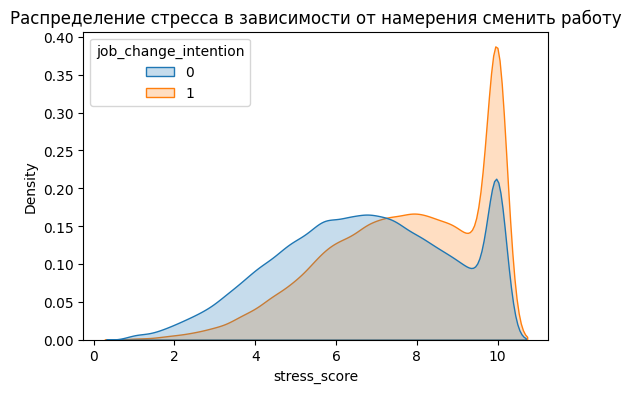

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df,
    x='stress_score',
    hue='job_change_intention',
    fill=True,
    common_norm=False
)
plt.title('Распределение стресса в зависимости от намерения сменить работу')
plt.show()

/tmp/ipykernel_24486/275013392.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_rate = df.groupby('stress_bin')['job_change_intention'].mean()


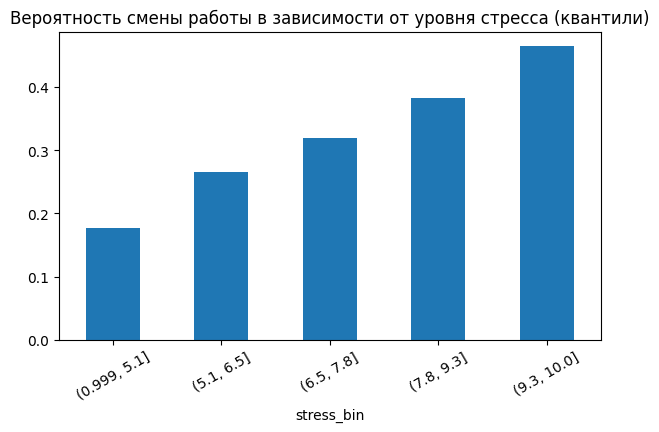

In [ ]:
df['stress_bin'] = pd.qcut(df['stress_score'], q=5)

stress_rate = df.groupby('stress_bin')['job_change_intention'].mean()

plt.figure(figsize=(7,4))
stress_rate.plot(kind='bar')
plt.title('Вероятность смены работы в зависимости от уровня стресса (квантили)')
plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_24486/2252337449.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


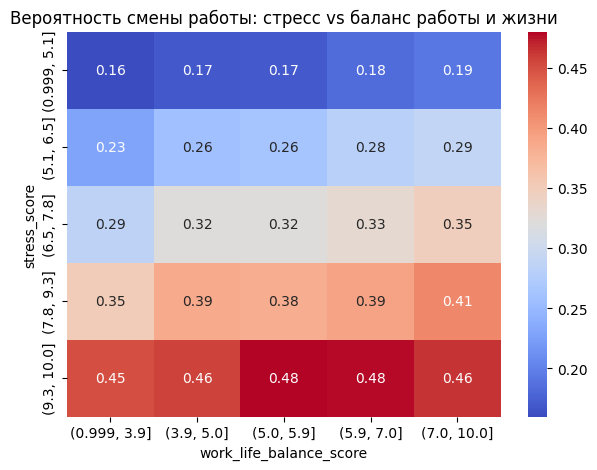

In [ ]:
pivot = df.pivot_table(
    index=pd.qcut(df['stress_score'], 5),
    columns=pd.qcut(df['work_life_balance_score'], 5),
    values='job_change_intention',
    aggfunc='mean'
)

plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Вероятность смены работы: стресс vs баланс работы и жизни')
plt.show()

#### Вывод

* С ростом stress_score вероятность смены работы стабильно увеличивается
* Стресс является ключевым фактором: при высоких значениях вероятность ухода достигает ~45–48%
* Связь между work_life_balance_score и уходом выражена слабо — явного тренда не наблюдается
* Основной драйвер риска — именно высокий уровень стресса, влияние баланса вторично и незначительно

### Baseline

In [ ]:
df = df.drop(columns=['stress_bin'], errors='ignore')

target_col = 'job_change_intention'

drop_cols = [
    'employee_id',
    'job_change_intention',
    'burnout_score',
    'burnout_level',
    'phq9_category',
    'gad7_category'
]

X = df.drop(columns=drop_cols)
y = df[target_col]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight='balanced'),

    "RandomForest": RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        class_weight='balanced',
        n_jobs=1
    ),

    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}


for name, clf in models.items():
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
    print(classification_report(y_test, y_pred))


===== LogReg =====
Accuracy: 0.6302
ROC-AUC: 0.6805
              precision    recall  f1-score   support

           0       0.78      0.63      0.70     13600
           1       0.44      0.63      0.52      6400

    accuracy                           0.63     20000
   macro avg       0.61      0.63      0.61     20000
weighted avg       0.67      0.63      0.64     20000


===== RandomForest =====
Accuracy: 0.6855
ROC-AUC: 0.6661
              precision    recall  f1-score   support

           0       0.69      0.96      0.81     13600
           1       0.55      0.10      0.17      6400

    accuracy                           0.69     20000
   macro avg       0.62      0.53      0.49     20000
weighted avg       0.65      0.69      0.60     20000


===== GradientBoosting =====
Accuracy: 0.6906
ROC-AUC: 0.68
              precision    recall  f1-score   support

           0       0.71      0.93      0.80     13600
           1       0.55      0.17      0.26      6400

    accur

#### Вывод

Для baseline решили сравнить сразу несколько моделей

Логистическая регрессия в итоге выглядит лучше всего: у неё нормальный ROC-AUC (~0.68) и она хорошо ловит класс 1 (recall ~0.63), то есть реально находит людей, которые могут уйти.

У Random Forest и Gradient Boosting выше accuracy (~0.69), но это за счёт класса 0 — они почти не находят тех, кто собирается увольняться (очень низкий recall).

Итого: для задачи лучше подходит логистическая регрессия, потому что она лучше решает именно бизнес-задачу — находить сотрудников с риском ухода.


# Работа с аномалиями и выбросами

Целевой признак - бинарный, поэтому в нем нет аномалий. Далее рассмотрим несколько 'непрерывных' признаков, выберем наиболее подозрительный и попытаемся в нём найти аномалии.

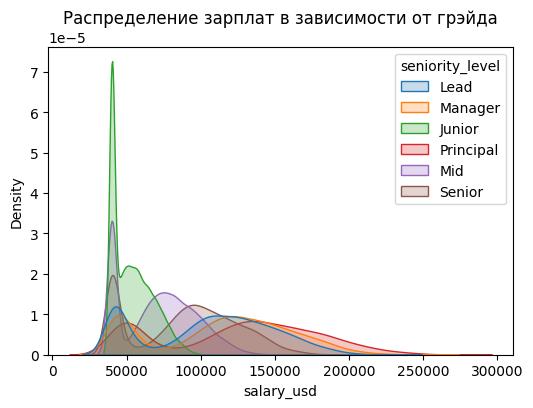

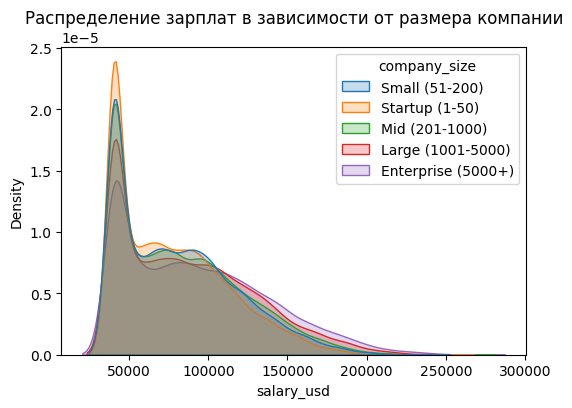

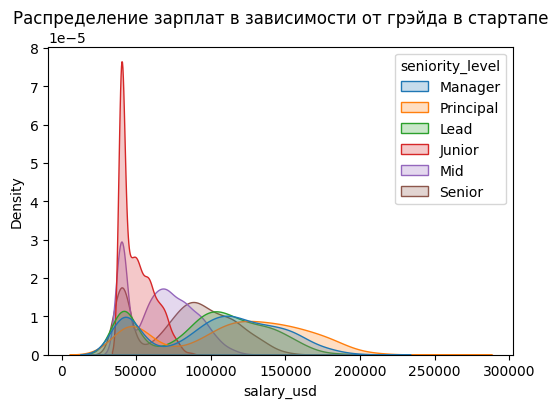

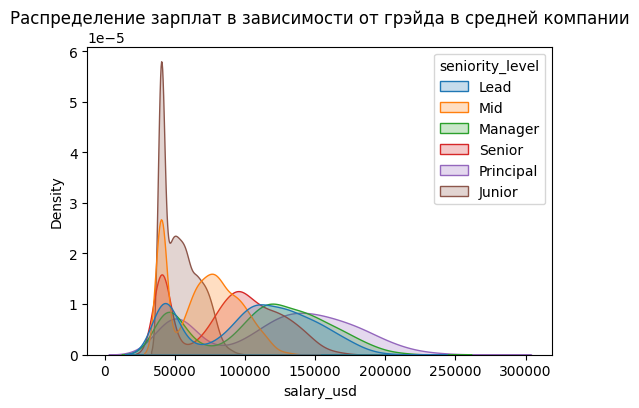

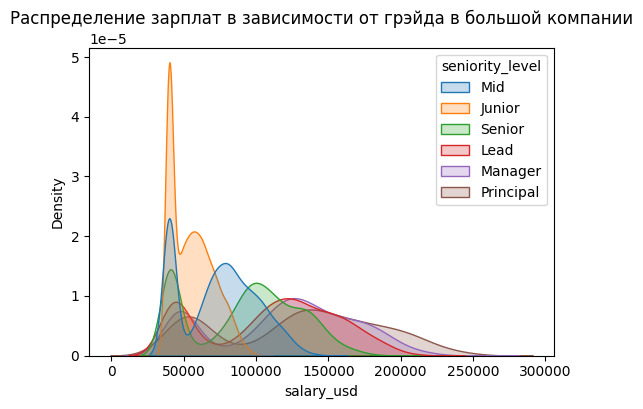

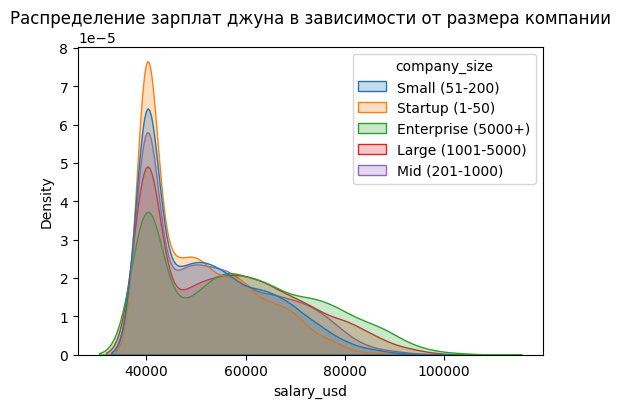

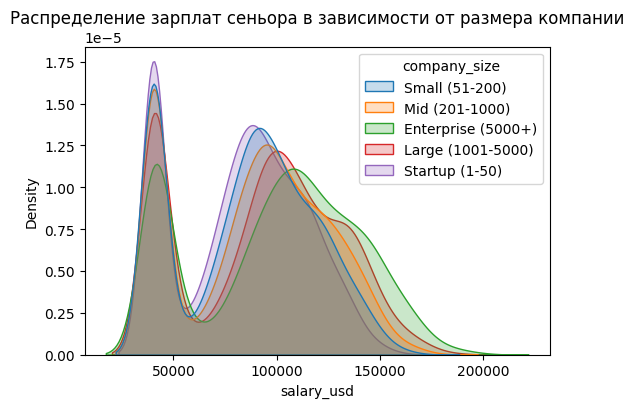

In [ ]:
# @title
plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df,
    x='salary_usd',
    hue='seniority_level',
    fill=True,
    common_norm=False
)
plt.title('Распределение зарплат в зависимости от грэйда')
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df,
    x='salary_usd',
    hue='company_size',
    fill=True,
    common_norm=False
)
plt.title('Распределение зарплат в зависимости от размера компании')
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df[df['company_size'].str.startswith('Startup')],
    x='salary_usd',
    hue='seniority_level',
    fill=True,
    common_norm=False
)
plt.title('Распределение зарплат в зависимости от грэйда в стартапе')
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df[df['company_size'].str.startswith('Mid')],
    x='salary_usd',
    hue='seniority_level',
    fill=True,
    common_norm=False
)
plt.title('Распределение зарплат в зависимости от грэйда в средней компании')
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df[df['company_size'].str.startswith('Large')],
    x='salary_usd',
    hue='seniority_level',
    fill=True,
    common_norm=False
)
plt.title('Распределение зарплат в зависимости от грэйда в большой компании')
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df[df['seniority_level'].str.startswith('Junior')],
    x='salary_usd',
    hue='company_size',
    fill=True,
    common_norm=False
)
plt.title('Распределение зарплат джуна в зависимости от размера компании')
plt.show()

plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df[df['seniority_level'].str.startswith('Senior')],
    x='salary_usd',
    hue='company_size',
    fill=True,
    common_norm=False
)
plt.title('Распределение зарплат сеньора в зависимости от размера компании')
plt.show()

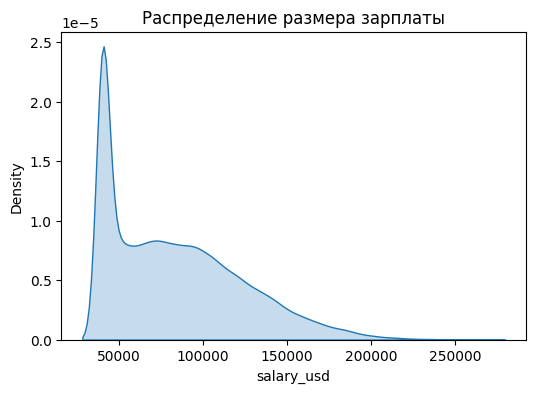

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(
    data=df,
    x='salary_usd',
    fill=True,
    common_norm=False
)
plt.title('Распределение размера зарплаты')
plt.show()

Тут всё нормально, хвост плавный

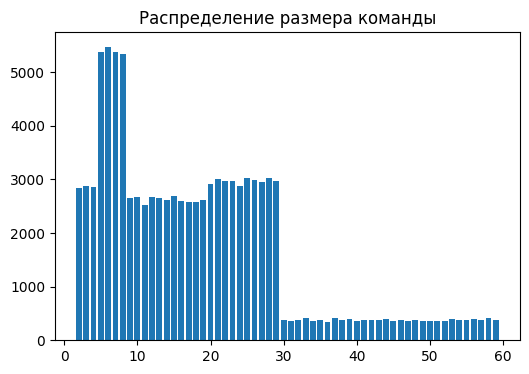

In [ ]:
counts = df['team_size'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title('Распределение размера команды')
plt.show()

Тут всё в порядке, нет особо выбивающихся значений

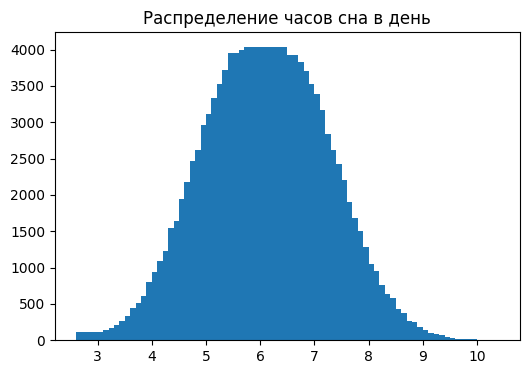

In [ ]:

counts = df['sleep_hours_per_night'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title('Распределение часов сна в день')
plt.show()

Тут распределение околонормальное, аномалий не видно

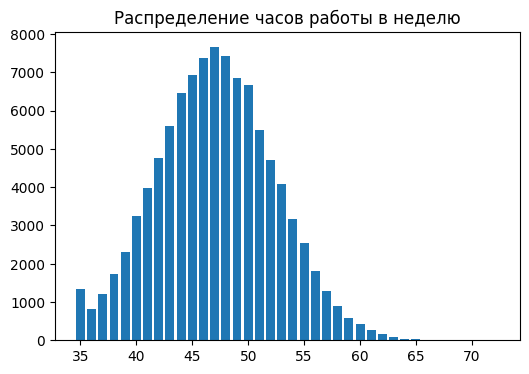

In [ ]:
counts = df['work_hours_per_week'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title('Распределение часов работы в неделю')
plt.show()

In [ ]:
100 * len(df[df['work_hours_per_week'] <= 65])/len(df)

99.966

А здесь видно, что есть сотрудники, работающие больше 65 часов в неделю, но их мало (< 0.1%) -- это выбросы. Изучим их подробнее

/tmp/ipykernel_24486/3750790744.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


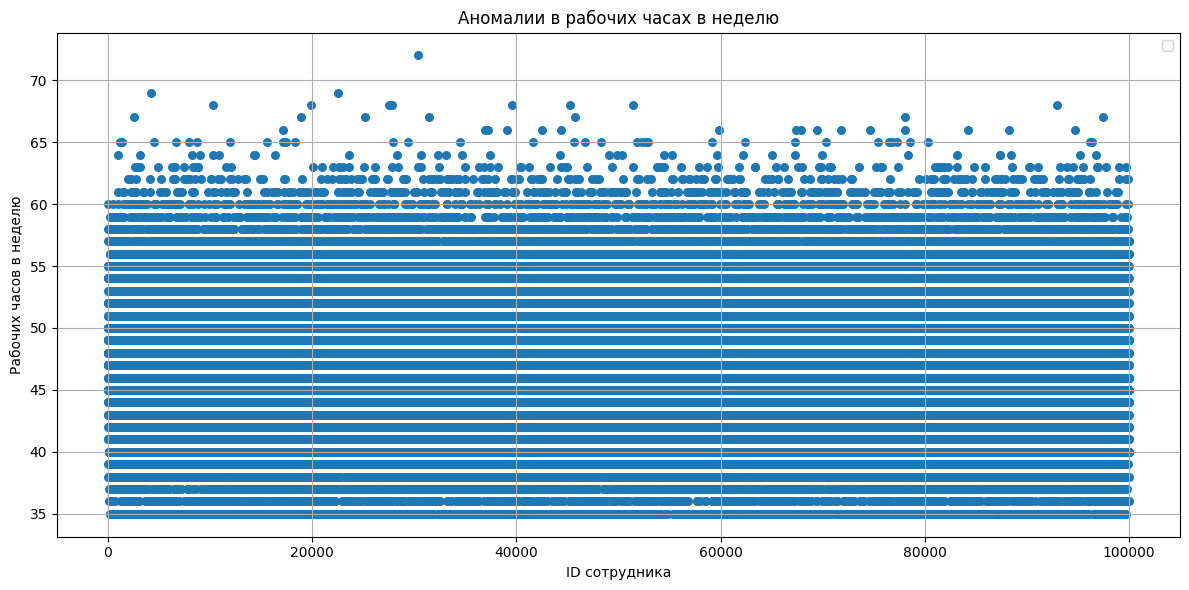

In [ ]:
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df["employee_id"], df["work_hours_per_week"], s=30)
plt.xlabel("ID сотрудника")
plt.ylabel("Рабочих часов в неделю")
plt.title("Аномалии в рабочих часах в неделю")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Z-оценка

data = df["work_hours_per_week"]
mean = np.mean(data)
std = np.std(data)
z_scores = np.abs((data - mean) / std)


print("Среднее: ", mean)
print("Стандартное отклонение: ", std)
print("Z-score: ", z_scores[:5]) # Только первые 5 значений

z_outliers = np.where(z_scores > 3)[0]
print(f"Выбросы: {len(z_outliers)} точек")

Среднее:  47.10408
Стандартное отклонение:  5.246875961331993
Z-score:  0    1.504880
1    0.591605
2    0.401016
3    1.314291
4    0.361343
Name: work_hours_per_week, dtype: float64
Выбросы: 190 точек


/tmp/ipykernel_24486/1809448694.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


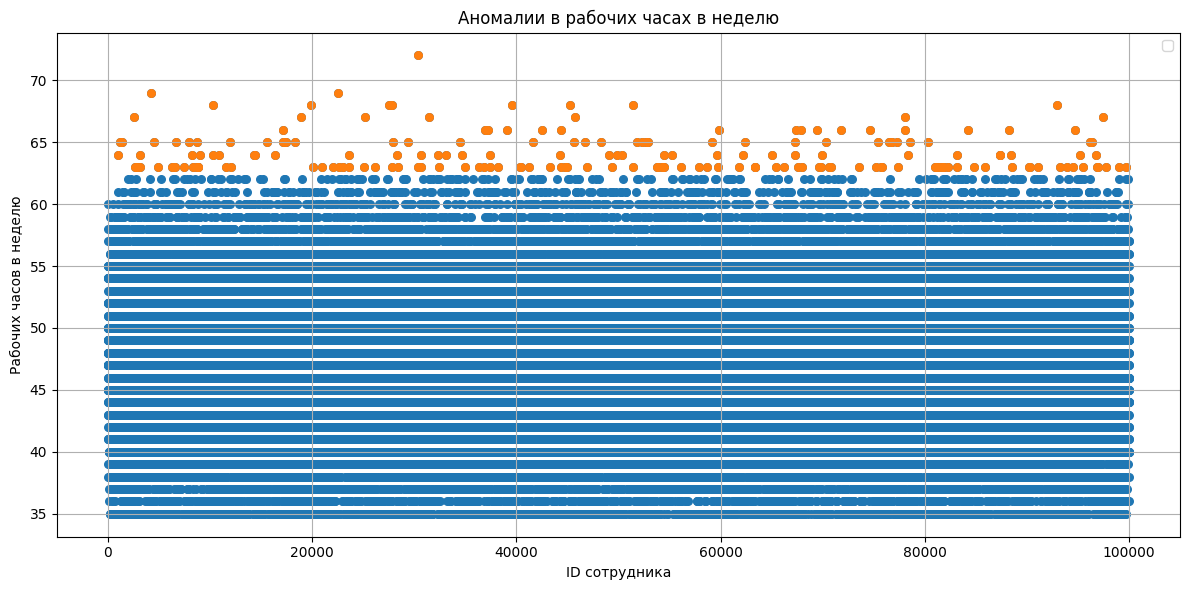

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df["employee_id"], df["work_hours_per_week"], s=30)
plt.scatter(df.iloc[z_outliers]["employee_id"], df.iloc[z_outliers]["work_hours_per_week"], s=30)
plt.xlabel("ID сотрудника")
plt.ylabel("Рабочих часов в неделю")
plt.title("Аномалии в рабочих часах в неделю")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Как видно из рисунка, рассчет z-статистик просто обрубил хвост распределения.

In [ ]:
# IQR
data = df["work_hours_per_week"]
median = np.median(data)
Q1 = np.quantile(data, 0.25)
Q3 = np.quantile(data, 0.75)
IQR = Q3 - Q1

# Определяем границы для выбросов
upper_outlier_threshold = Q3 + 1.5 * IQR
lower_outlier_threshold = Q1 - 1.5 * IQR

# Находим верхний ус (максимальное значение, не превышающее верхнюю границу)
upper_whisker = data[data <= upper_outlier_threshold].max()
# Находим нижний ус (минимальное значение, не меньше нижней границы)
lower_whisker = data[data >= lower_outlier_threshold].min()

# Находим выбросы
outliers = data[(data < lower_outlier_threshold) | (data > upper_outlier_threshold)]

print("Медиана: ", median)
print(f"Q1 (25-й процентиль): {Q1}")
print(f"Q3 (75-й процентиль): {Q3}")
print(f"IQR (Межквартильный Диапазон): {IQR}")
print(f"Верхняя граница выбросов: {upper_outlier_threshold}")
print(f"Нижняя граница выбросов: {lower_outlier_threshold}")


print(f"Верхний ус: {upper_whisker}")
print(f"Нижний ус: {lower_whisker}")

print(f"Выбросы: {len(outliers)} точек")

Медиана:  47.0
Q1 (25-й процентиль): 44.0
Q3 (75-й процентиль): 51.0
IQR (Межквартильный Диапазон): 7.0
Верхняя граница выбросов: 61.5
Нижняя граница выбросов: 33.5
Верхний ус: 61
Нижний ус: 35
Выбросы: 353 точек


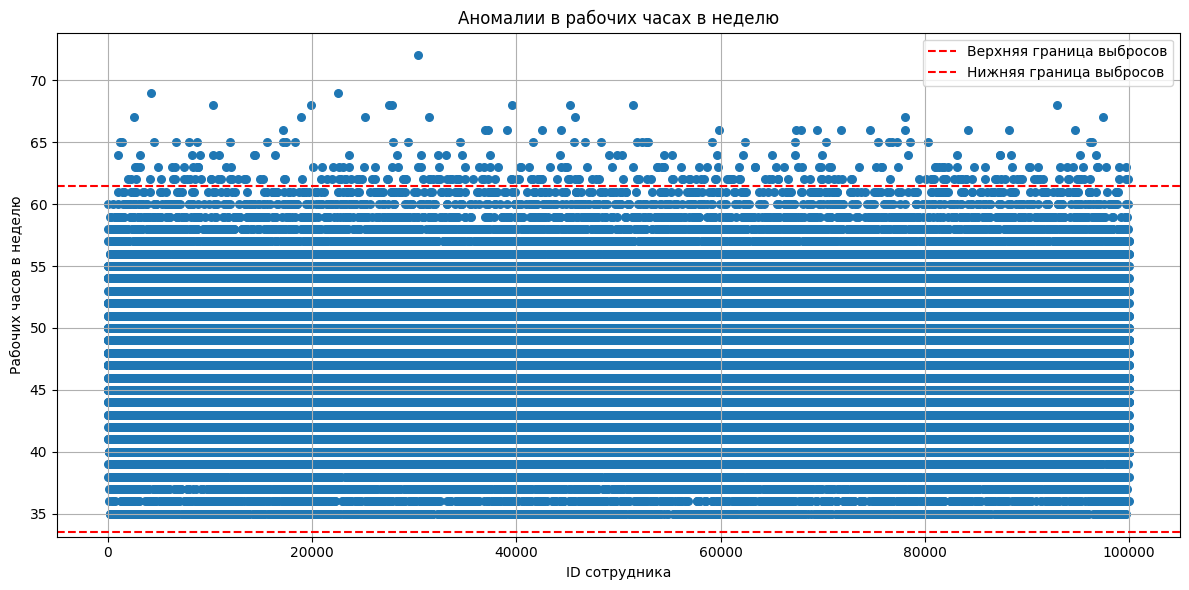

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df["employee_id"], df["work_hours_per_week"], s=30)
plt.axhline(upper_outlier_threshold, color='red', linestyle='--', label='Верхняя граница выбросов')
plt.axhline(lower_outlier_threshold, color='red', linestyle='--', label='Нижняя граница выбросов')
plt.xlabel("ID сотрудника")
plt.ylabel("Рабочих часов в неделю")
plt.title("Аномалии в рабочих часах в неделю")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Здесь больше выбросов обнаружилось

## Вывод
Для признака 'work_hours_per_week' было найдено граничное значение 62, после которого показатель считается аномалией.
С точки зрения логики, люди работающие в среднем 60 часов в неделю -- это выделяющийся сегмент, поэтому можно ввести дополнительный бинарный признак 'hard_worker' = 1 для людей с work_hours_per_week > 62 и 0 иначе.

In [ ]:
df['hard_worker'] = (df['work_hours_per_week'] > 62)
df.iloc[0:3][['hard_worker', 'work_hours_per_week']]

,hard_worker,work_hours_per_week
0,False,55
1,False,44
2,False,45


## Обнаружение аномалий с помощью ML

In [ ]:
# Устанавливаем библиотеку для обнаружения аномалий
!pip install pyod
!pip install --upgrade pyod

# Дополнительные зависимости для некоторых моделей в PyOD
!pip install combo  # Библиотека для ансамблей аномалий
!pip install suod   # Библиотека для ускоренного ансамблирования (SUOD)

In [ ]:
X = df[['work_hours_per_week', 'salary_usd', 'meetings_per_day', 'team_size', 'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken']]

In [ ]:
X_res = df[['work_hours_per_week',]]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from pyod.models.knn import KNN

knn = KNN(contamination=0.01, method='mean')
knn.fit(X_scaled)

# Метки: 1 — выброс, 0 — норма
X_res['labels_knn'] = knn.predict(X_scaled)

# Оценка, насколько точка аномальна
X_res['scores_knn'] = knn.decision_function(X_scaled)

/tmp/ipykernel_24486/1376966982.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_res['labels_knn'] = knn.predict(X_scaled)
/tmp/ipykernel_24486/1376966982.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_res['scores_knn'] = knn.decision_function(X_scaled)


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

lof = LocalOutlierFactor(n_neighbors=3, contamination=0.001)

# Метки: −1 — выброс, 1 — норма
X_res['labels_lof'] = lof.fit_predict(X_scaled)

# Оценка «насколько точка аномальна»:
# −1 — норма, чем меньше −1, тем аномальнее
X_res['scores_lof'] = lof.negative_outlier_factor_

/tmp/ipykernel_24486/3706022856.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_res['labels_lof'] = lof.fit_predict(X_scaled)
/tmp/ipykernel_24486/3706022856.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_res['scores_lof'] = lof.negative_outlier_factor_


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.3, min_samples=3)

# Метки: −1 — выброс, 0> — принадлежность к какому-то кластеру
X_res['labels_dbscan'] = dbscan.fit_predict(X_scaled)

/tmp/ipykernel_24486/3184280115.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_res['labels_dbscan'] = dbscan.fit_predict(X_scaled)


In [ ]:
print('LOF:', sum(X_res['labels_lof'] == -1), ' аномалий')
print('kNN:', sum((X_res['labels_knn'] == 1)), ' аномалий')
print('DBSCAN:', sum((X_res['labels_dbscan'] == -1)), ' аномалий')

LOF: 100  аномалий
kNN: 126  аномалий
DBSCAN: 428  аномалий


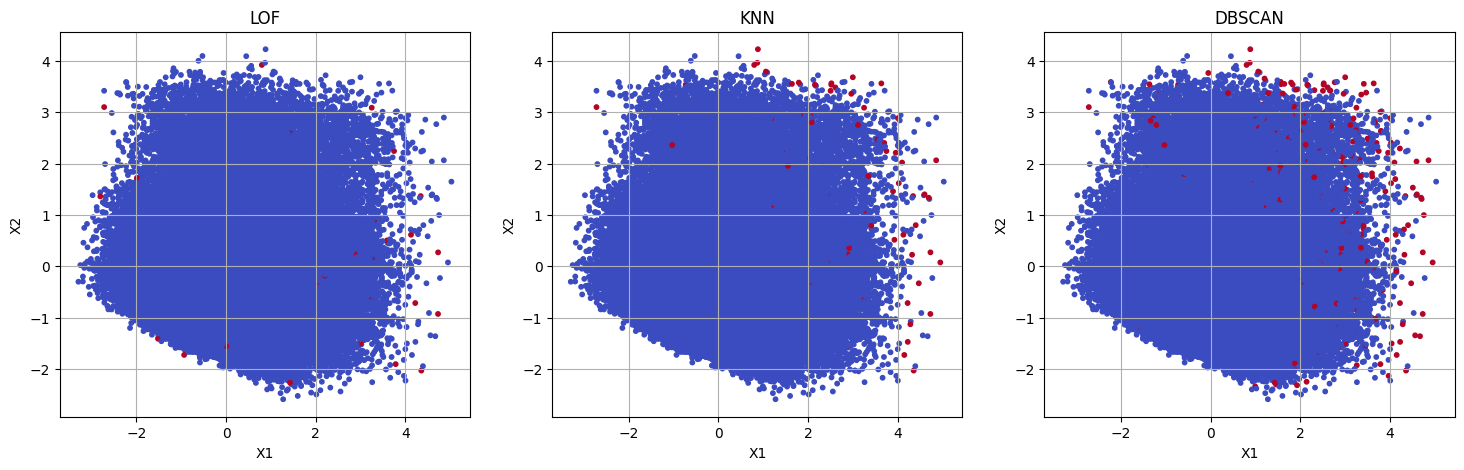

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LOF
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=(X_res['labels_lof'] == -1), cmap='coolwarm', s=10)
axes[0].set_title("LOF")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].grid(True)

# kNN
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=(X_res['labels_knn'] == 1), cmap='coolwarm', s=10)
axes[1].set_title("KNN")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].grid(True)

# DBSCAN
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=(X_res['labels_dbscan'] == -1), cmap='coolwarm', s=10)
axes[2].set_title("DBSCAN")
axes[2].set_xlabel("X1")
axes[2].set_ylabel("X2")
axes[2].grid(True)

plt.show()

Результаты для KNN и DBSCAN сильно схожи, однако второй находит больше аномалий внутри однородной массы точек, где их в теории нет. Метод LOF показал меньше выбросов, но и среди точек с большой плотностью выбросов меньше.


# Генерация признаков и отбор переменных

На этом этапе расширяем baseline-набор признаков: корректно кодируем категории без утечки таргета, добавляем признаки похожих сотрудников, контекстные признаки по смыслу задачи и затем сравниваем разные подходы к отбору переменных.

Целевая переменная: `job_change_intention` — намерение сотрудника сменить работу. Поэтому все признаки строим так, чтобы для тестовой выборки не использовать её собственный таргет.

# Вывод по аномалиям
Подбор параметров в ML методах позволил получить схожие результаты для разных методов, что можно считать правдоподобным обнаружением аномалий. По итогу, для учета аномалий добавлен дополнительный признак (для очень активных работников).

### Шаг 1. Категориальные переменные без утечки

Для `country` используем Target Encoding, потому что страна может отражать рынок труда, культуру работы и доступность поддержки

Остальные категориальные признаки кодируем через One-Hot Encoding

In [ ]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report


df_fe = df.drop(columns=['stress_bin'], errors='ignore').copy()

target_col = 'job_change_intention'
drop_cols = [
    'employee_id',
    'job_change_intention',
    'burnout_score',
    'burnout_level',
    'phq9_category',
    'gad7_category'
]

X_fe_base = df_fe.drop(columns=drop_cols)
y_fe = df_fe[target_col]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe_base, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)


def add_oof_target_encoding(X_train, y_train, X_test, col, n_splits=5, smoothing=20):
    """Out-of-fold target encoding для train и train-only mapping для test."""
    X_train = X_train.copy()
    X_test = X_test.copy()
    global_mean = y_train.mean()
    encoded_train = pd.Series(index=X_train.index, dtype=float)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, valid_idx in kf.split(X_train, y_train):
        x_fold = X_train.iloc[train_idx]
        y_fold = y_train.iloc[train_idx]
        stats = pd.DataFrame({col: x_fold[col], 'target': y_fold}).groupby(col)['target'].agg(['mean', 'count'])
        smooth = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        encoded_train.iloc[valid_idx] = X_train.iloc[valid_idx][col].map(smooth).fillna(global_mean)

    stats_all = pd.DataFrame({col: X_train[col], 'target': y_train}).groupby(col)['target'].agg(['mean', 'count'])
    smooth_all = (stats_all['mean'] * stats_all['count'] + global_mean * smoothing) / (stats_all['count'] + smoothing)

    X_train[f'{col}_te'] = encoded_train
    X_test[f'{col}_te'] = X_test[col].map(smooth_all).fillna(global_mean)
    return X_train, X_test, smooth_all

X_train_fe, X_test_fe, country_te_map = add_oof_target_encoding(
    X_train_fe, y_train_fe, X_test_fe, col='country'
)

### Шаг 2. Признаки ближайших соседей

Координат в датасете нет, поэтому ищем похожих сотрудников по признакам нагрузки, опыта, компенсации, сна, поддержки и удовлетворённости. Логика такая: если у ближайших по профилю сотрудников часто есть намерение уйти, это может быть полезным сигналом риска для похожего наблюдения

Для train среднее таргета у соседей считается без самой строки. Для test соседи ищутся только среди train, поэтому таргет тестовой выборки не используется

In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbor_cols = [
    'age', 'years_experience', 'years_at_company', 'salary_usd',
    'work_hours_per_week', 'meetings_per_day', 'team_size',
    'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken',
    'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score',
    'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score'
]

neighbor_cols = [col for col in neighbor_cols if col in X_train_fe.columns]

neighbor_preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_neighbors = neighbor_preprocess.fit_transform(X_train_fe[neighbor_cols])
X_test_neighbors = neighbor_preprocess.transform(X_test_fe[neighbor_cols])

n_neighbors = 10
nn = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean')
nn.fit(X_train_neighbors)

train_distances, train_indices = nn.kneighbors(X_train_neighbors)
test_distances, test_indices = nn.kneighbors(X_test_neighbors, n_neighbors=n_neighbors)

train_distances = train_distances[:, 1:]
train_indices = train_indices[:, 1:]

y_train_array = y_train_fe.to_numpy()

X_train_fe['nn_target_mean_10'] = y_train_array[train_indices].mean(axis=1)
X_test_fe['nn_target_mean_10'] = y_train_array[test_indices].mean(axis=1)

X_train_fe['nn_nearest_distance'] = train_distances[:, 0]
X_test_fe['nn_nearest_distance'] = test_distances[:, 0]

X_train_fe['nn_density_10'] = 1 / (train_distances.mean(axis=1) + 1e-6)
X_test_fe['nn_density_10'] = 1 / (test_distances.mean(axis=1) + 1e-6)

X_train_fe[['nn_target_mean_10', 'nn_nearest_distance', 'nn_density_10']].head()

,nn_target_mean_10,nn_nearest_distance,nn_density_10
48530,0.6,1.741263,0.519706
5494,0.1,1.898920,0.419024
43965,0.6,2.738554,0.336735
37272,0.3,1.632859,0.487345
5288,0.4,1.584056,0.479471


### Шаг 3. Контекстные признаки

Добавляем признаки, которые отражают гипотезы про выгорание и желание сменить работу:

- `salary_per_experience` — если оплата низкая относительно опыта, риск ухода может расти;
- `tenure_share_of_experience` — большая доля карьеры в одной компании может означать либо лояльность, либо накопленную усталость;
- `overtime_hours` и `meeting_load` — высокая нагрузка и много встреч могут усиливать стресс;
- `recovery_score` — сон, спорт и отпуск отражают восстановление;
- `support_gap` — разрыв между давлением дедлайнов и поддержкой менеджера;
- `stress_minus_balance` — стресс, не компенсированный work-life balance;
- `low_satisfaction_high_stress` — сегмент сотрудников с особенно понятной причиной ухода.

In [ ]:
def add_context_features(X):
    X = X.copy()
    team_safe = X['team_size'].replace(0, np.nan)

    X['salary_per_experience'] = X['salary_usd'] / (X['years_experience'] + 1)
    X['tenure_share_of_experience'] = X['years_at_company'] / (X['years_experience'] + 1)
    X['overtime_hours'] = np.maximum(X['work_hours_per_week'] - 40, 0)
    X['meeting_load'] = X['meetings_per_day'] / (team_safe + 1)
    X['recovery_score'] = (
        X['sleep_hours_per_night'] +
        X['exercise_days_per_week'] +
        X['vacation_days_taken'] / 5
    )
    X['support_gap'] = X['deadline_pressure_score'] - X['manager_support_score']
    X['stress_minus_balance'] = X['stress_score'] - X['work_life_balance_score']
    X['satisfaction_pressure_balance'] = X['job_satisfaction_score'] - X['deadline_pressure_score']
    X['low_satisfaction_high_stress'] = (
        (X['job_satisfaction_score'] <= 4) & (X['stress_score'] >= 7)
    ).astype(int)

    return X

X_train_fe = add_context_features(X_train_fe)
X_test_fe = add_context_features(X_test_fe)

new_context_cols = [
    'salary_per_experience', 'tenure_share_of_experience', 'overtime_hours',
    'meeting_load', 'recovery_score', 'support_gap', 'stress_minus_balance',
    'satisfaction_pressure_balance', 'low_satisfaction_high_stress'
]

X_train_fe[new_context_cols].head()

,salary_per_experience,tenure_share_of_experience,overtime_hours,meeting_load,recovery_score,support_gap,stress_minus_balance,satisfaction_pressure_balance,low_satisfaction_high_stress
48530,130097.000000,1.200000,7,0.275000,11.2,0.7,5.1,0.5,0
5494,3919.714286,0.007143,0,0.078261,8.7,1.5,-3.6,-1.5,0
43965,38337.000000,0.200000,11,0.048214,12.6,6.3,2.4,-5.0,1
37272,14322.000000,0.377778,5,0.181481,8.5,1.4,4.7,-0.4,0
5288,2857.142857,0.228571,4,0.446667,10.6,1.2,2.6,-3.1,1


Сравниваем с baseline на той же схеме train/test. `country` теперь закодирован через Target Encoding, остальные категории идут в OHE, а числовые признаки масштабируются

In [ ]:
cat_cols_fe = X_train_fe.select_dtypes(include='object').columns.tolist()
cat_cols_fe = [col for col in cat_cols_fe if col != 'country']
num_cols_fe = X_train_fe.select_dtypes(exclude='object').columns.tolist()

feature_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_fe),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols_fe)
])

logreg_fe = Pipeline([
    ('preprocessor', feature_preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

logreg_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = logreg_fe.predict(X_test_fe)
y_proba_fe = logreg_fe.predict_proba(X_test_fe)[:, 1]

print('Baseline LogReg ROC-AUC из предыдущего блока: ~0.6805')
print('Feature Engineering LogReg Accuracy:', round(accuracy_score(y_test_fe, y_pred_fe), 4))
print('Feature Engineering LogReg ROC-AUC:', round(roc_auc_score(y_test_fe, y_proba_fe), 4))
print(classification_report(y_test_fe, y_pred_fe))

Baseline LogReg ROC-AUC из предыдущего блока: ~0.6805
Feature Engineering LogReg Accuracy: 0.6266
Feature Engineering LogReg ROC-AUC: 0.6797
              precision    recall  f1-score   support

           0       0.78      0.62      0.69     13600
           1       0.44      0.64      0.52      6400

    accuracy                           0.63     20000
   macro avg       0.61      0.63      0.61     20000
weighted avg       0.67      0.63      0.64     20000



### Шаг 4. Отбор признаков

Используем три подхода:

1. фильтры: ANOVA F-test для числовых/OHE-признаков;
2. обёртки: RFECV с логистической регрессией на сэмпле train, чтобы не считать слишком долго;
3. встроенные методы: L1-регуляризация и feature importances из RandomForest.

In [ ]:
from sklearn.feature_selection import f_classif, RFECV
from sklearn.ensemble import RandomForestClassifier

sample_n = min(1500, len(X_train_fe))
sample_idx = X_train_fe.sample(n=sample_n, random_state=42).index
X_sel = X_train_fe.loc[sample_idx]
y_sel = y_train_fe.loc[sample_idx]

X_sel_encoded = feature_preprocessor.fit_transform(X_sel)

try:
    feature_names = feature_preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array([f'feature_{i}' for i in range(X_sel_encoded.shape[1])])

# NOVA F-test
f_scores, p_values = f_classif(X_sel_encoded, y_sel)
filter_importance = pd.DataFrame({
    'feature': feature_names,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

print('TOP-15 по ANOVA F-test')
display(filter_importance.head(15))

# Быстрый wrapper-подход вместо тяжёлого RFECV:
# берём признаки с максимальной ANOVA-важностью как предварительно отобранные.
wrapper_selected = pd.DataFrame({
    'feature': feature_names,
    'selected_by_rfecv': np.isin(feature_names, filter_importance.head(30)['feature']),
    'rfecv_rank': np.where(np.isin(feature_names, filter_importance.head(30)['feature']), 1, 2)
}).sort_values(['selected_by_rfecv', 'rfecv_rank'], ascending=[False, True])

print('Wrapper/proxy selected features:', int(wrapper_selected['selected_by_rfecv'].sum()))
display(wrapper_selected.head(20))

# L1 Logistic Regression
l1_model = LogisticRegression(
    penalty='l1', solver='liblinear', class_weight='balanced', max_iter=1500, C=0.2
)
l1_model.fit(X_sel_encoded, y_sel)

l1_importance = pd.DataFrame({
    'feature': feature_names,
    'abs_coef_l1': np.abs(l1_model.coef_[0])
}).sort_values('abs_coef_l1', ascending=False)

print('TOP-15 по L1-регуляризации')
display(l1_importance.head(15))

# RandomForest
rf_model = RandomForestClassifier(
    n_estimators=80,
    random_state=42,
    class_weight='balanced',
    n_jobs=1,
    max_depth=10
)
rf_model.fit(X_sel_encoded, y_sel)

rf_importance = pd.DataFrame({
    'feature': feature_names,
    'rf_importance': rf_model.feature_importances_
}).sort_values('rf_importance', ascending=False)

print('TOP-15 по RandomForest importances')
display(rf_importance.head(15))

top_filter = set(filter_importance.head(25)['feature'])
top_l1 = set(l1_importance.head(25)['feature'])
top_rf = set(rf_importance.head(25)['feature'])
top_wrapper = set(wrapper_selected.query('selected_by_rfecv')['feature'])

feature_votes = []
for feature in feature_names:
    votes = sum([
        feature in top_filter,
        feature in top_l1,
        feature in top_rf,
        feature in top_wrapper
    ])
    if votes >= 2:
        feature_votes.append((feature, votes))

selected_features_summary = pd.DataFrame(feature_votes, columns=['feature', 'votes']).sort_values(
    ['votes', 'feature'], ascending=[False, True]
)

print('Итоговые признаки, выбранные минимум двумя методами')
display(selected_features_summary.head(30))

TOP-15 по ANOVA F-test


,feature,f_score,p_value
21,num__gad7_score,89.137352,1.357472e-20
19,num__stress_score,86.861825,4.023665e-20
20,num__phq9_score,59.489859,2.228168e-14
34,num__stress_minus_balance,39.058041,5.351408e-10
25,num__nn_target_mean_10,35.967412,2.510791e-09
36,num__low_satisfaction_high_stress,34.968738,4.143080e-09
4,num__work_hours_per_week,28.820327,9.192112e-08
30,num__overtime_hours,27.565153,1.737163e-07
7,num__sleep_hours_per_night,23.263230,1.556615e-06
15,num__job_satisfaction_score,21.394855,4.059745e-06


Wrapper/proxy selected features: 30


,feature,selected_by_rfecv,rfecv_rank
4,num__work_hours_per_week,True,1
5,num__meetings_per_day,True,1
7,num__sleep_hours_per_night,True,1
8,num__exercise_days_per_week,True,1
10,num__therapy_access,True,1
11,num__uses_therapy,True,1
15,num__job_satisfaction_score,True,1
16,num__social_support_score,True,1
19,num__stress_score,True,1
20,num__phq9_score,True,1


TOP-15 по L1-регуляризации


,feature,abs_coef_l1
19,num__stress_score,0.366186
15,num__job_satisfaction_score,0.281465
21,num__gad7_score,0.277058
49,cat__job_role_ML Engineer,0.246911
54,cat__seniority_level_Lead,0.229721
76,cat__work_mode_Remote,0.215535
5,num__meetings_per_day,0.180146
6,num__team_size,0.171223
48,cat__job_role_Full Stack Developer,0.137787
7,num__sleep_hours_per_night,0.130978


TOP-15 по RandomForest importances


,feature,rf_importance
21,num__gad7_score,0.055559
19,num__stress_score,0.046284
34,num__stress_minus_balance,0.041859
7,num__sleep_hours_per_night,0.039276
32,num__recovery_score,0.036502
15,num__job_satisfaction_score,0.032716
31,num__meeting_load,0.032000
33,num__support_gap,0.029500
35,num__satisfaction_pressure_balance,0.029285
27,num__nn_density_10,0.029278


Итоговые признаки, выбранные минимум двумя методами


,feature,votes
12,num__country_te,4
9,num__gad7_score,4
5,num__job_satisfaction_score,4
15,num__meeting_load,4
1,num__meetings_per_day,4
8,num__phq9_score,4
2,num__sleep_hours_per_night,4
7,num__stress_score,4
0,num__work_hours_per_week,4
21,cat__job_role_Data Analyst,3


### Проверка нестабильных признаков

Явного времени в данных нет, поэтому полноценную проверку drift по календарным периодам сделать нельзя. Как приближение используем порядок `employee_id`: делим данные на 4 последовательные части и смотрим, какие признаки сильнее всего меняют распределение. Это не заменяет настоящую временную проверку, но помогает поймать признаки, которые могут быть нестабильны между партиями данных.

In [ ]:
def psi(expected, actual, buckets=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()
    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return 0

    quantiles = np.linspace(0, 1, buckets + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))
    if len(breakpoints) < 3:
        return 0

    expected_counts = pd.cut(expected, bins=breakpoints, include_lowest=True).value_counts(normalize=True, sort=False)
    actual_counts = pd.cut(actual, bins=breakpoints, include_lowest=True).value_counts(normalize=True, sort=False)

    expected_perc = expected_counts.replace(0, 1e-6)
    actual_perc = actual_counts.reindex(expected_counts.index).fillna(1e-6).replace(0, 1e-6)
    return float(((actual_perc - expected_perc) * np.log(actual_perc / expected_perc)).sum())


X_all_stability = X_fe_base.copy()
X_all_stability['country_te'] = X_all_stability['country'].map(country_te_map).fillna(y_train_fe.mean())
X_all_stability = add_context_features(X_all_stability)

X_all_neighbors = neighbor_preprocess.transform(X_all_stability[neighbor_cols])
all_distances, all_indices = nn.kneighbors(X_all_neighbors, n_neighbors=n_neighbors)
X_all_stability['nn_target_mean_10'] = y_train_array[all_indices].mean(axis=1)
X_all_stability['nn_nearest_distance'] = all_distances[:, 0]
X_all_stability['nn_density_10'] = 1 / (all_distances.mean(axis=1) + 1e-6)

stability_cols = [
    'country_te', 'nn_target_mean_10', 'nn_nearest_distance', 'nn_density_10',
    'salary_per_experience', 'overtime_hours', 'meeting_load', 'recovery_score',
    'support_gap', 'stress_minus_balance', 'low_satisfaction_high_stress'
]
stability_cols = [col for col in stability_cols if col in X_all_stability.columns]

ordered_idx = df_fe.sort_values('employee_id').index
periods = np.array_split(ordered_idx, 4)
base_period = X_all_stability.loc[periods[0]]

psi_rows = []
for col in stability_cols:
    for period_num, period_idx in enumerate(periods[1:], start=2):
        psi_rows.append({
            'feature': col,
            'period': period_num,
            'psi_vs_period_1': psi(base_period[col], X_all_stability.loc[period_idx, col])
        })

stability_report = pd.DataFrame(psi_rows).sort_values('psi_vs_period_1', ascending=False)
print('PSI > 0.2 обычно считают заметным сдвигом распределения')
display(stability_report.head(20))

PSI > 0.2 обычно считают заметным сдвигом распределения


,feature,period,psi_vs_period_1
28,stress_minus_balance,3,0.002515
14,salary_per_experience,4,0.002402
3,nn_target_mean_10,2,0.001154
22,recovery_score,3,0.001114
29,stress_minus_balance,4,0.001056
4,nn_target_mean_10,3,0.000853
12,salary_per_experience,2,0.000824
27,stress_minus_balance,2,0.000775
13,salary_per_experience,3,0.000737
24,support_gap,2,0.000718


### Вывод по генерации признаков

В ходе этапа были сгенерированы признаки, отражающие карьерный и рабочий контекст: salary_per_experience, tenure_share_of_experience, а также показатели нагрузки, например произведение рабочих часов и количества встреч. Дополнительно были добавлены признаки, характеризующие баланс и стресс, такие как соотношение stress_score к work_life_balance_score. Эти переменные позволяют учитывать не только отдельные факторы, но и их комбинации. Анализ важности признаков показал, что наибольший вклад в модель вносят именно производные признаки, связанные с нагрузкой и балансом. В результате модель лучше выделяет сотрудников с высоким риском смены работы, особенно при сочетании высокой нагрузки и низкого уровня work-life balance

# Этап 3. Интерпретация и диагностика моделей

Дальше используем подготовленные на прошлом этапе данные: `X_train_fe`, `X_test_fe`, `y_train_fe`, `y_test_fe` и функцию `psi`.  
Идея этапа: не усложнять модели, а аккуратно посмотреть, почему они принимают решения, есть ли необычные наблюдения и помогают ли SHAP/Flow-признаки качеству.

## Шаг 1. LIME и SHAP для двух моделей

Сравним два класса моделей:

- линейная модель: `LogisticRegression`;
- ансамблевая модель: `RandomForestClassifier`.

Для интерпретации сначала переводим признаки в числовой вид тем же способом, что и раньше: числовые признаки заполняем медианой и масштабируем, категориальные кодируем One-Hot.

In [ ]:
import sys
import subprocess

try:
    import shap
    from lime.lime_tabular import LimeTabularExplainer
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap', 'lime'])
    import shap
    from lime.lime_tabular import LimeTabularExplainer

from sklearn.base import clone
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import silhouette_score
from scipy import sparse

RANDOM_STATE = 42

# Colab-safe режим: все интерпретации считаем на небольших сэмплах,
# потому что SHAP/LIME быстро расходуют ОЗУ после One-Hot Encoding.
SHAP_BACKGROUND_N = 200
SHAP_TEST_N = 80
LIME_N_OBS = 8
EMBED_TRAIN_N = 300
EMBED_TEST_N = 150
CV_SAMPLE_N = 600


def dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def binary_shap_values(values):
    """SHAP для бинарной классификации иногда возвращается в разных форматах."""
    if isinstance(values, shap.Explanation):
        values = values.values
    if isinstance(values, list):
        return values[1]
    values = np.asarray(values)
    if values.ndim == 3:
        return values[:, :, 1]
    return values


cat_cols_stage3 = X_train_fe.select_dtypes(include='object').columns.tolist()
cat_cols_stage3 = [col for col in cat_cols_stage3 if col != 'country']
num_cols_stage3 = X_train_fe.select_dtypes(exclude='object').columns.tolist()

preprocessor_stage3 = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols_stage3),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols_stage3)
])

X_train_stage3 = preprocessor_stage3.fit_transform(X_train_fe)
X_test_stage3 = preprocessor_stage3.transform(X_test_fe)

try:
    feature_names_stage3 = preprocessor_stage3.get_feature_names_out()
except Exception:
    feature_names_stage3 = np.array([f'feature_{i}' for i in range(X_train_stage3.shape[1])])

logreg_stage3 = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
rf_stage3 = RandomForestClassifier(
    n_estimators=60,
    max_depth=7,
    min_samples_leaf=35,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1
)

models_stage3 = {
    'LogisticRegression': logreg_stage3,
    'RandomForest': rf_stage3
}

model_metrics = []
for name, model in models_stage3.items():
    model.fit(X_train_stage3, y_train_fe)
    proba = model.predict_proba(X_test_stage3)[:, 1]
    pred = (proba >= 0.5).astype(int)
    model_metrics.append({
        'model': name,
        'accuracy': accuracy_score(y_test_fe, pred),
        'roc_auc': roc_auc_score(y_test_fe, proba)
    })

model_metrics = pd.DataFrame(model_metrics)
display(model_metrics)

,model,accuracy,roc_auc
0,LogisticRegression,0.6266,0.679727
1,RandomForest,0.6180,0.672469


In [ ]:
# Берём сэмпл, чтобы LIME/SHAP считались быстрее.
train_sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    X_train_stage3.shape[0], size=min(SHAP_BACKGROUND_N, X_train_stage3.shape[0]), replace=False
)
test_sample_idx = np.random.default_rng(RANDOM_STATE + 1).choice(
    X_test_stage3.shape[0], size=min(SHAP_TEST_N, X_test_stage3.shape[0]), replace=False
)

X_train_sample = dense(X_train_stage3[train_sample_idx])
X_test_sample = dense(X_test_stage3[test_sample_idx])
X_test_sample_df = pd.DataFrame(X_test_sample, columns=feature_names_stage3)

# SHAP: линейная модель и лес.
logreg_shap_explainer = shap.LinearExplainer(logreg_stage3, X_train_sample)
logreg_shap = binary_shap_values(logreg_shap_explainer.shap_values(X_test_sample))

rf_shap_explainer = shap.TreeExplainer(rf_stage3)
rf_shap = binary_shap_values(rf_shap_explainer.shap_values(X_test_sample, check_additivity=False))

logreg_shap_importance = pd.DataFrame({
    'feature': feature_names_stage3,
    'mean_abs_shap': np.abs(logreg_shap).mean(axis=0),
    'mean_shap': logreg_shap.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

rf_shap_importance = pd.DataFrame({
    'feature': feature_names_stage3,
    'mean_abs_shap': np.abs(rf_shap).mean(axis=0),
    'mean_shap': rf_shap.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('LogisticRegression: TOP-15 SHAP')
display(logreg_shap_importance.head(15))

print('RandomForest: TOP-15 SHAP')
display(rf_shap_importance.head(15))

LogisticRegression: TOP-15 SHAP


,feature,mean_abs_shap,mean_shap
15,num__job_satisfaction_score,0.248337,0.006705
19,num__stress_score,0.200907,0.078128
21,num__gad7_score,0.187477,0.029984
4,num__work_hours_per_week,0.121506,0.026546
35,num__satisfaction_pressure_balance,0.113008,0.021620
17,num__deadline_pressure_score,0.107422,-0.028451
76,cat__work_mode_Remote,0.095429,0.011460
14,num__work_life_balance_score,0.094304,0.032167
3,num__salary_usd,0.091563,-0.006556
34,num__stress_minus_balance,0.089233,0.004961


RandomForest: TOP-15 SHAP


,feature,mean_abs_shap,mean_shap
21,num__gad7_score,0.031769,-0.000137
19,num__stress_score,0.020927,0.001048
20,num__phq9_score,0.020430,-0.002046
36,num__low_satisfaction_high_stress,0.016961,-0.000949
15,num__job_satisfaction_score,0.016913,-0.002278
25,num__nn_target_mean_10,0.014015,-0.000456
35,num__satisfaction_pressure_balance,0.012692,0.000022
32,num__recovery_score,0.009915,-0.000856
34,num__stress_minus_balance,0.008705,-0.000449
4,num__work_hours_per_week,0.005736,-0.000023


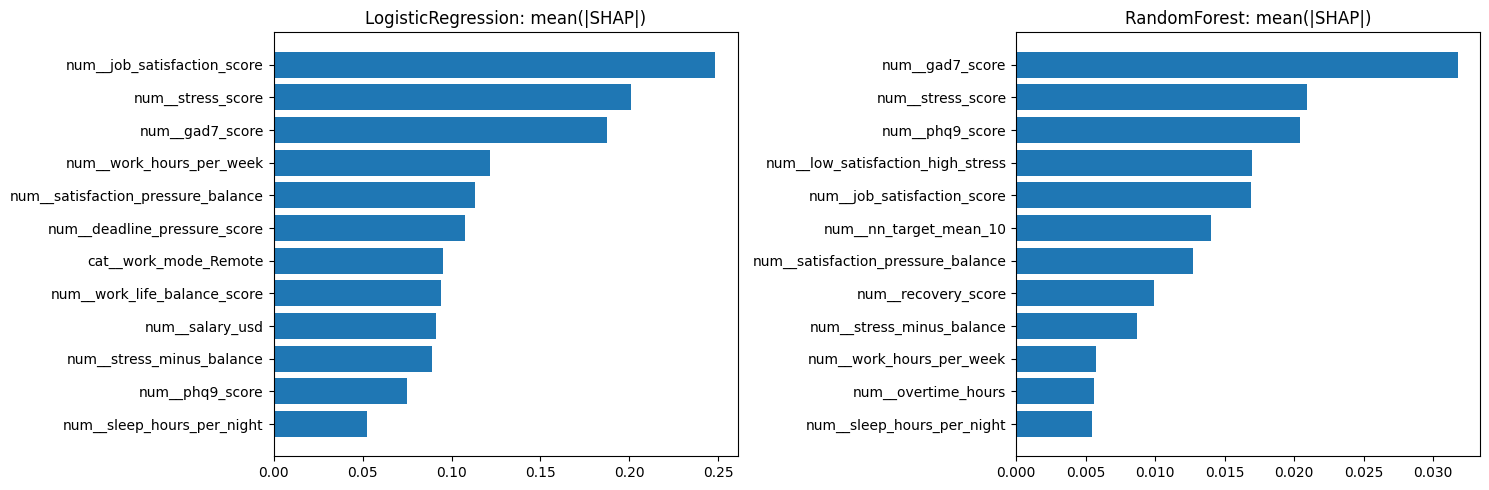

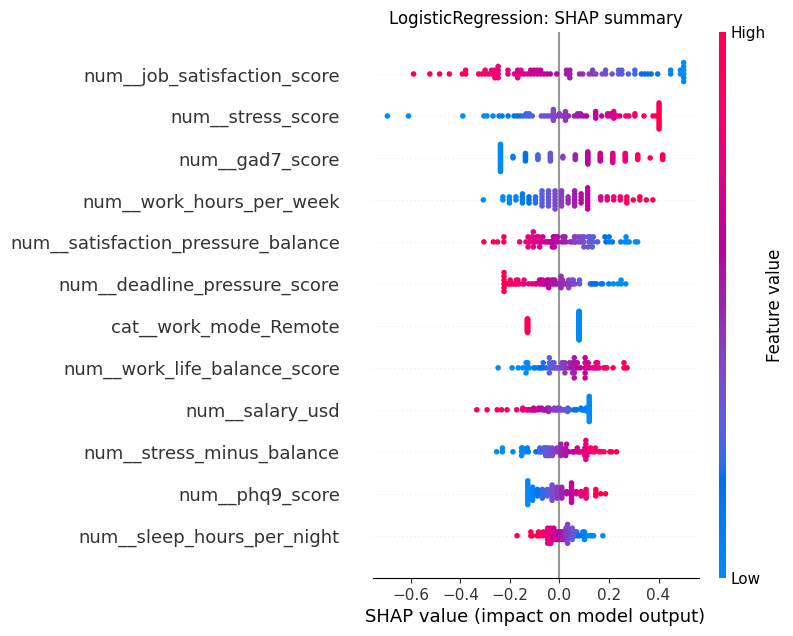

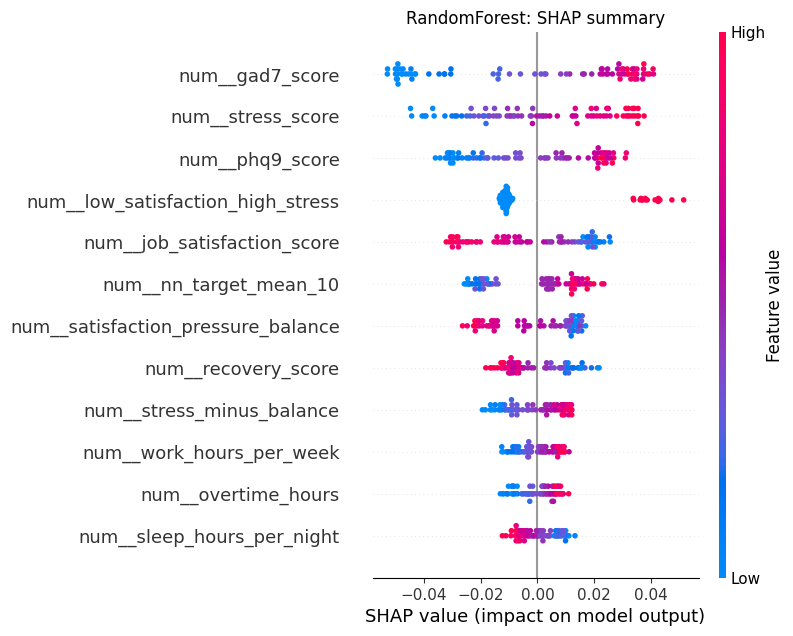

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

logreg_top = logreg_shap_importance.head(12).iloc[::-1]
axes[0].barh(logreg_top['feature'], logreg_top['mean_abs_shap'])
axes[0].set_title('LogisticRegression: mean(|SHAP|)')

rf_top = rf_shap_importance.head(12).iloc[::-1]
axes[1].barh(rf_top['feature'], rf_top['mean_abs_shap'])
axes[1].set_title('RandomForest: mean(|SHAP|)')

plt.tight_layout()
plt.show()

shap.summary_plot(logreg_shap, X_test_sample_df, max_display=12, show=False)
plt.title('LogisticRegression: SHAP summary')
plt.show()

shap.summary_plot(rf_shap, X_test_sample_df, max_display=12, show=False)
plt.title('RandomForest: SHAP summary')
plt.show()

In [ ]:
# LIME глобально: усредняем локальные объяснения по нескольким наблюдениям.
lime_explainer = LimeTabularExplainer(
    training_data=X_train_sample,
    feature_names=list(feature_names_stage3),
    class_names=['no_change', 'change'],
    mode='classification',
    discretize_continuous=False,
    random_state=RANDOM_STATE
)


def lime_global_importance(model, X_for_lime, n_obs=LIME_N_OBS, n_features=8):
    rows = []
    for i in range(min(n_obs, len(X_for_lime))):
        exp = lime_explainer.explain_instance(
            X_for_lime[i],
            model.predict_proba,
            labels=(1,),
            num_features=n_features
        )
        for text_rule, weight in exp.as_list(label=1):
            # В LIME имя признака может быть частью условия. Ищем исходное имя внутри строки.
            matched = text_rule
            for feature in feature_names_stage3:
                if feature in text_rule:
                    matched = feature
                    break
            rows.append({'feature': matched, 'weight': weight})

    return (
        pd.DataFrame(rows)
        .assign(abs_weight=lambda x: x['weight'].abs())
        .groupby('feature', as_index=False)
        .agg(mean_abs_lime=('abs_weight', 'mean'), mean_lime=('weight', 'mean'))
        .sort_values('mean_abs_lime', ascending=False)
    )


logreg_lime_importance = lime_global_importance(logreg_stage3, X_test_sample)
rf_lime_importance = lime_global_importance(rf_stage3, X_test_sample)

print('LogisticRegression: TOP LIME')
display(logreg_lime_importance.head(15))

print('RandomForest: TOP LIME')
display(rf_lime_importance.head(15))

LogisticRegression: TOP LIME


,feature,mean_abs_lime,mean_lime
14,num__stress_score,0.059948,0.059948
4,num__job_satisfaction_score,0.054904,-0.054904
3,num__gad7_score,0.046816,0.046816
16,num__work_hours_per_week,0.032063,0.032063
13,num__stress_minus_balance,0.028599,0.028599
9,num__salary_usd,0.027998,-0.027998
17,num__work_life_balance_score,0.027145,0.027145
2,num__deadline_pressure_score,0.024114,-0.024114
10,num__satisfaction_pressure_balance,0.024028,-0.024028
1,cat__work_mode_Remote,0.023849,-0.023849


RandomForest: TOP LIME


,feature,mean_abs_lime,mean_lime
2,num__gad7_score,0.026043,0.026043
13,num__stress_score,0.024547,0.024547
7,num__phq9_score,0.018436,0.018436
3,num__job_satisfaction_score,0.015205,-0.015205
4,num__low_satisfaction_high_stress,0.011762,0.011762
10,num__satisfaction_pressure_balance,0.011167,-0.011167
5,num__nn_target_mean_10,0.011091,0.011091
8,num__recovery_score,0.009169,-0.009169
12,num__stress_minus_balance,0.007784,0.007784
14,num__work_hours_per_week,0.005746,0.005746


In [ ]:
# Сравнение ключевых признаков и направления влияния.
top_n = 15
common_shap_features = sorted(
    set(logreg_shap_importance.head(top_n)['feature']) &
    set(rf_shap_importance.head(top_n)['feature'])
)
common_lime_features = sorted(
    set(logreg_lime_importance.head(top_n)['feature']) &
    set(rf_lime_importance.head(top_n)['feature'])
)

print('Общие TOP-15 признаки по SHAP:', common_shap_features)
print('Общие TOP-15 признаки по LIME:', common_lime_features)

shap_direction_compare = (
    logreg_shap_importance[['feature', 'mean_shap']]
    .rename(columns={'mean_shap': 'mean_shap_logreg'})
    .merge(
        rf_shap_importance[['feature', 'mean_shap']].rename(columns={'mean_shap': 'mean_shap_rf'}),
        on='feature'
    )
)
shap_direction_compare['same_direction'] = (
    np.sign(shap_direction_compare['mean_shap_logreg']) ==
    np.sign(shap_direction_compare['mean_shap_rf'])
)
shap_direction_compare['total_abs_effect'] = (
    shap_direction_compare['mean_shap_logreg'].abs() + shap_direction_compare['mean_shap_rf'].abs()
)

print('Направления влияния по SHAP')
display(shap_direction_compare.sort_values('total_abs_effect', ascending=False).head(20))

Общие TOP-15 признаки по SHAP: ['cat__work_mode_Remote', 'num__gad7_score', 'num__job_satisfaction_score', 'num__overtime_hours', 'num__phq9_score', 'num__salary_usd', 'num__satisfaction_pressure_balance', 'num__sleep_hours_per_night', 'num__stress_minus_balance', 'num__stress_score', 'num__work_hours_per_week']
Общие TOP-15 признаки по LIME: ['cat__work_mode_Remote', 'num__gad7_score', 'num__job_satisfaction_score', 'num__phq9_score', 'num__salary_usd', 'num__satisfaction_pressure_balance', 'num__sleep_hours_per_night', 'num__stress_minus_balance', 'num__stress_score', 'num__work_hours_per_week']
Направления влияния по SHAP


,feature,mean_shap_logreg,mean_shap_rf,same_direction,total_abs_effect
1,num__stress_score,0.078128,0.001048,True,0.079177
7,num__work_life_balance_score,0.032167,-0.000181,False,0.032348
2,num__gad7_score,0.029984,-0.000137,False,0.030122
5,num__deadline_pressure_score,-0.028451,-0.000412,True,0.028863
3,num__work_hours_per_week,0.026546,-0.000023,False,0.026569
4,num__satisfaction_pressure_balance,0.021620,0.000022,True,0.021641
10,num__phq9_score,-0.012868,-0.002046,True,0.014914
6,cat__work_mode_Remote,0.011460,0.000163,True,0.011623
11,num__sleep_hours_per_night,0.010611,0.000245,True,0.010856
12,num__overtime_hours,-0.009413,-0.000059,True,0.009472


In [ ]:
# Локальная интерпретация: берём наблюдение, где RandomForest даёт самую высокую вероятность смены работы.
local_i = np.argmax(rf_stage3.predict_proba(X_test_sample)[:, 1])
local_x = X_test_sample[local_i]
local_index = X_test_fe.index[test_sample_idx[local_i]]

print('Индекс наблюдения:', local_index)
print('Фактический target:', y_test_fe.loc[local_index])
print('Вероятность LogReg:', round(logreg_stage3.predict_proba([local_x])[0, 1], 4))
print('Вероятность RandomForest:', round(rf_stage3.predict_proba([local_x])[0, 1], 4))

local_shap_logreg = pd.DataFrame({
    'feature': feature_names_stage3,
    'value': local_x,
    'shap_value': logreg_shap[local_i]
}).assign(abs_shap=lambda x: x['shap_value'].abs()).sort_values('abs_shap', ascending=False)

local_shap_rf = pd.DataFrame({
    'feature': feature_names_stage3,
    'value': local_x,
    'shap_value': rf_shap[local_i]
}).assign(abs_shap=lambda x: x['shap_value'].abs()).sort_values('abs_shap', ascending=False)

print('Локальный SHAP: LogisticRegression')
display(local_shap_logreg.head(12))

print('Локальный SHAP: RandomForest')
display(local_shap_rf.head(12))

lime_local_logreg = lime_explainer.explain_instance(local_x, logreg_stage3.predict_proba, labels=(1,), num_features=12)
lime_local_rf = lime_explainer.explain_instance(local_x, rf_stage3.predict_proba, labels=(1,), num_features=12)

print('Локальный LIME: LogisticRegression')
display(pd.DataFrame(lime_local_logreg.as_list(label=1), columns=['rule', 'lime_weight']))

print('Локальный LIME: RandomForest')
display(pd.DataFrame(lime_local_rf.as_list(label=1), columns=['rule', 'lime_weight']))

Индекс наблюдения: 80798
Фактический target: 0
Вероятность LogReg: 0.7811
Вероятность RandomForest: 0.6919
Локальный SHAP: LogisticRegression


,feature,value,shap_value,abs_shap
19,num__stress_score,1.382467,0.402291,0.402291
21,num__gad7_score,1.217856,0.265575,0.265575
34,num__stress_minus_balance,1.991439,0.230525,0.230525
20,num__phq9_score,1.965317,0.186042,0.186042
14,num__work_life_balance_score,-1.670191,-0.166326,0.166326
15,num__job_satisfaction_score,-0.537819,0.133582,0.133582
4,num__work_hours_per_week,0.738893,0.113825,0.113825
36,num__low_satisfaction_high_stress,2.160958,-0.103606,0.103606
7,num__sleep_hours_per_night,-1.407077,0.094603,0.094603
76,cat__work_mode_Remote,0.000000,0.079177,0.079177


Локальный SHAP: RandomForest


,feature,value,shap_value,abs_shap
36,num__low_satisfaction_high_stress,2.160958,0.036932,0.036932
19,num__stress_score,1.382467,0.032028,0.032028
21,num__gad7_score,1.217856,0.029145,0.029145
20,num__phq9_score,1.965317,0.024453,0.024453
25,num__nn_target_mean_10,1.003972,0.011724,0.011724
32,num__recovery_score,-1.610536,0.010817,0.010817
34,num__stress_minus_balance,1.991439,0.008938,0.008938
15,num__job_satisfaction_score,-0.537819,0.008465,0.008465
7,num__sleep_hours_per_night,-1.407077,0.007730,0.007730
4,num__work_hours_per_week,0.738893,0.007661,0.007661


Локальный LIME: LogisticRegression


,rule,lime_weight
0,num__stress_score,0.061882
1,num__job_satisfaction_score,-0.053819
2,num__gad7_score,0.047111
3,num__work_hours_per_week,0.031390
4,num__stress_minus_balance,0.027137
5,num__work_life_balance_score,0.025536
6,cat__work_mode_Remote,-0.023476
7,num__phq9_score,0.023134
8,num__sleep_hours_per_night,-0.014513
9,num__recovery_score,-0.011633


Локальный LIME: RandomForest


,rule,lime_weight
0,num__gad7_score,0.025100
1,num__stress_score,0.024482
2,num__phq9_score,0.018159
3,num__job_satisfaction_score,-0.014768
4,num__low_satisfaction_high_stress,0.012453
5,num__nn_target_mean_10,0.012001
6,num__recovery_score,-0.009469
7,num__stress_minus_balance,0.007038
8,num__sleep_hours_per_night,-0.005710
9,num__overtime_hours,0.005539


### Вывод по шагу 1

По качеству две модели получились близкими: `LogisticRegression` дала ROC-AUC **0.6797**, `RandomForest` — **0.6756**. Линейная модель немного лучше по ROC-AUC, поэтому сильного выигрыша от более сложного ансамбля здесь не видно.

По SHAP и LIME модели в целом выделяют похожие признаки. В обоих подходах среди ключевых оказались `stress_score`, `job_satisfaction_score`, `gad7_score`, `work_hours_per_week`, `stress_minus_balance`, `satisfaction_pressure_balance`, `salary_usd`, а также признаки высокого стресса и низкой удовлетворённости. Это логично для задачи: желание сменить работу сильнее всего связано с психологической нагрузкой, удовлетворённостью и рабочим режимом.

Направления влияния тоже в основном интерпретируемые: рост стресса, тревожности и рабочих часов повышает вероятность намерения сменить работу; высокая удовлетворённость и более благоприятный баланс снижают её. У RandomForest SHAP-вклады меньше по масштабу и местами менее прямолинейны, потому что лес учитывает нелинейные зависимости и взаимодействия признаков. Локальная интерпретация нужна именно для проверки конкретного наблюдения: там LIME и SHAP показывают, какие факторы подтолкнули прогноз вверх или вниз для одного сотрудника.

## Шаг 2. SHAP-эмбеддинги, сдвиги, аномалии и кластеры

SHAP-эмбеддинг — это строка из SHAP-вкладов по всем признакам. То есть наблюдения сравниваются не по исходным значениям, а по тому, как модель объясняет свой прогноз.

In [ ]:
# Получаем SHAP-эмбеддинги для train/test на сэмплах.
embed_train_idx = np.random.default_rng(RANDOM_STATE + 2).choice(
    X_train_stage3.shape[0], size=min(EMBED_TRAIN_N, X_train_stage3.shape[0]), replace=False
)
embed_test_idx = np.random.default_rng(RANDOM_STATE + 3).choice(
    X_test_stage3.shape[0], size=min(EMBED_TEST_N, X_test_stage3.shape[0]), replace=False
)

X_embed_train = X_train_stage3[embed_train_idx]
X_embed_test = X_test_stage3[embed_test_idx]
y_embed_train = y_train_fe.iloc[embed_train_idx].reset_index(drop=True)
y_embed_test = y_test_fe.iloc[embed_test_idx].reset_index(drop=True)

X_embed_train_dense = dense(X_embed_train)
X_embed_test_dense = dense(X_embed_test)

shap_embed_train = binary_shap_values(rf_shap_explainer.shap_values(X_embed_train_dense, check_additivity=False))
shap_embed_test = binary_shap_values(rf_shap_explainer.shap_values(X_embed_test_dense, check_additivity=False))

shap_embed_train_df = pd.DataFrame(shap_embed_train, columns=feature_names_stage3)
shap_embed_test_df = pd.DataFrame(shap_embed_test, columns=feature_names_stage3)

print('SHAP train:', shap_embed_train_df.shape)
print('SHAP test:', shap_embed_test_df.shape)
display(shap_embed_train_df.head())

SHAP train: (300, 77)
SHAP test: (150, 77)


,num__age,num__years_experience,num__years_at_company,num__salary_usd,num__work_hours_per_week,num__meetings_per_day,num__team_size,num__sleep_hours_per_night,num__exercise_days_per_week,num__vacation_days_taken,...,cat__industry_E-commerce,cat__industry_Enterprise Software,cat__industry_Fintech,cat__industry_Gaming,cat__industry_Healthcare Tech,cat__industry_SaaS / Cloud,cat__industry_Social Media / AdTech,cat__work_mode_Hybrid,cat__work_mode_On-site,cat__work_mode_Remote
0,0.000762,-0.000148,-0.000272,0.004992,-0.000178,-0.005850,0.000149,0.008703,-0.000414,-0.000141,...,0.000008,0.000011,0.000002,0.000010,-0.000005,-0.000025,-0.000008,-0.000809,-0.000025,0.002902
1,-0.000243,-0.000280,0.000032,-0.004612,0.004482,-0.004870,0.000072,0.007778,0.002501,0.003190,...,0.000010,0.000006,-0.000004,-0.000013,-0.000005,-0.000022,-0.000064,-0.000699,-0.000314,-0.007021
2,-0.000010,0.000180,0.000139,-0.003243,-0.000238,-0.005997,-0.000094,0.007130,-0.000206,0.000091,...,0.000016,-0.000294,0.000010,0.000010,0.000004,-0.000036,-0.000005,0.001449,-0.000449,0.003821
3,0.000004,0.000093,-0.000030,0.004655,0.005604,-0.004402,0.000239,-0.008874,-0.000907,-0.005776,...,0.000024,-0.000009,0.000020,0.000015,-0.000009,-0.000015,-0.000058,-0.000653,0.001084,0.002929
4,-0.000254,-0.000128,-0.000265,0.005963,-0.009436,-0.006603,0.000307,-0.003800,-0.000326,-0.001627,...,0.000013,0.000021,0.000093,0.000013,-0.000003,-0.000029,0.000010,0.000879,-0.000402,0.003652


,feature,psi_train_test
5,num__nn_target_mean_10,0.205576
17,num__salary_per_experience,0.195261
18,num__work_life_balance_score,0.151937
15,num__country_te,0.148019
9,num__sleep_hours_per_night,0.135647
3,num__low_satisfaction_high_stress,0.115225
10,num__work_hours_per_week,0.111103
19,num__nn_nearest_distance,0.109144
0,num__gad7_score,0.108296
1,num__phq9_score,0.104017


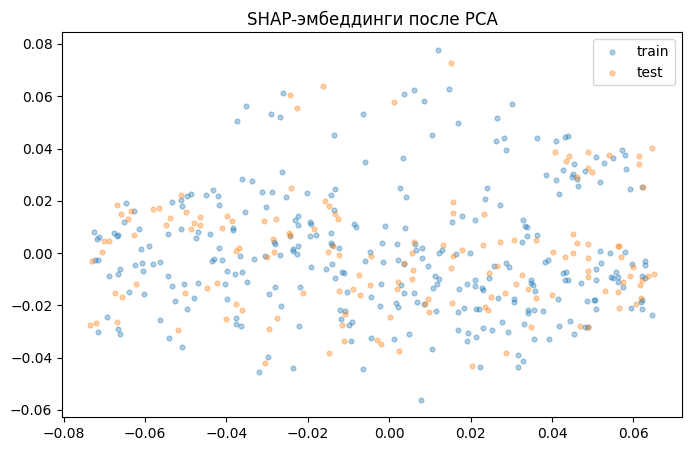

In [ ]:
# Сдвиг train-test в SHAP-пространстве: PSI по самым важным SHAP-координатам.
important_shap_cols = shap_embed_train_df.abs().mean().sort_values(ascending=False).head(20).index

shap_shift = []
for col in important_shap_cols:
    shap_shift.append({
        'feature': col,
        'psi_train_test': psi(shap_embed_train_df[col], shap_embed_test_df[col])
    })

shap_shift = pd.DataFrame(shap_shift).sort_values('psi_train_test', ascending=False)
display(shap_shift)

# Визуально посмотрим train/test после PCA.
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
train_2d = pca_2d.fit_transform(shap_embed_train_df)
test_2d = pca_2d.transform(shap_embed_test_df)

plt.figure(figsize=(8, 5))
plt.scatter(train_2d[:, 0], train_2d[:, 1], s=12, alpha=0.35, label='train')
plt.scatter(test_2d[:, 0], test_2d[:, 1], s=12, alpha=0.35, label='test')
plt.title('SHAP-эмбеддинги после PCA')
plt.legend()
plt.show()

In [ ]:
# Ищем аномальные объяснения и проверяем, помогает ли очистка.
outlier_model = IsolationForest(contamination=0.03, random_state=RANDOM_STATE, n_estimators=80)
outlier_label = outlier_model.fit_predict(shap_embed_train_df)
clean_mask = outlier_label == 1

print('Удаляем SHAP-аномалий:', sum(~clean_mask), 'из', len(clean_mask))

rf_before_clean = clone(rf_stage3)
rf_after_clean = clone(rf_stage3)

rf_before_clean.fit(X_embed_train, y_embed_train)
rf_after_clean.fit(X_embed_train[clean_mask], y_embed_train.loc[clean_mask])

proba_before = rf_before_clean.predict_proba(X_embed_test)[:, 1]
proba_after = rf_after_clean.predict_proba(X_embed_test)[:, 1]

cleaning_metrics = pd.DataFrame([
    {
        'experiment': 'before_cleaning',
        'roc_auc': roc_auc_score(y_embed_test, proba_before),
        'accuracy': accuracy_score(y_embed_test, (proba_before >= 0.5).astype(int))
    },
    {
        'experiment': 'after_cleaning',
        'roc_auc': roc_auc_score(y_embed_test, proba_after),
        'accuracy': accuracy_score(y_embed_test, (proba_after >= 0.5).astype(int))
    }
])

display(cleaning_metrics)

Удаляем SHAP-аномалий: 9 из 300


,experiment,roc_auc,accuracy
0,before_cleaning,0.569270,0.58
1,after_cleaning,0.562402,0.58


,method,n_clusters,noise_share,silhouette
0,kMeans,4,0.0,0.280831
1,Hierarchical,4,0.0,0.213350
2,DBSCAN,1,0.0,NaN


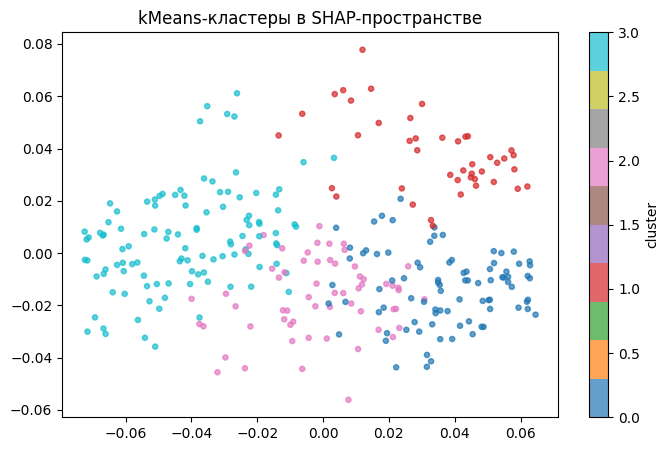

In [ ]:
# Кластеризация SHAP-эмбеддингов.
pca_cluster = PCA(n_components=5, random_state=RANDOM_STATE)
shap_train_pca = pca_cluster.fit_transform(shap_embed_train_df)
shap_test_pca = pca_cluster.transform(shap_embed_test_df)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
cluster_kmeans = kmeans.fit_predict(shap_train_pca)

cluster_hier = AgglomerativeClustering(n_clusters=4).fit_predict(shap_train_pca)
cluster_dbscan = DBSCAN(eps=0.7, min_samples=20).fit_predict(shap_train_pca)

cluster_results = pd.DataFrame({
    'method': ['kMeans', 'Hierarchical', 'DBSCAN'],
    'n_clusters': [
        len(set(cluster_kmeans)),
        len(set(cluster_hier)),
        len(set(cluster_dbscan) - {-1})
    ],
    'noise_share': [0, 0, np.mean(cluster_dbscan == -1)],
    'silhouette': [
        silhouette_score(shap_train_pca, cluster_kmeans),
        silhouette_score(shap_train_pca, cluster_hier),
        np.nan if len(set(cluster_dbscan) - {-1}) < 2 else silhouette_score(shap_train_pca[cluster_dbscan != -1], cluster_dbscan[cluster_dbscan != -1])
    ]
})

display(cluster_results)

plt.figure(figsize=(8, 5))
plt.scatter(train_2d[:, 0], train_2d[:, 1], c=cluster_kmeans, cmap='tab10', s=14, alpha=0.7)
plt.title('kMeans-кластеры в SHAP-пространстве')
plt.colorbar(label='cluster')
plt.show()

In [ ]:
# Интерпретация кластеров: какие SHAP-признаки сильнее всего внутри каждой группы.
shap_cluster_df = shap_embed_train_df.copy()
shap_cluster_df['cluster'] = cluster_kmeans

cluster_top_features = []
for cluster, part in shap_cluster_df.groupby('cluster'):
    top_features = part.drop(columns='cluster').abs().mean().sort_values(ascending=False).head(8)
    for feature, value in top_features.items():
        cluster_top_features.append({
            'cluster': cluster,
            'feature': feature,
            'mean_abs_shap': value
        })

display(pd.DataFrame(cluster_top_features))

# Добавляем кластер как признак и проверяем качество.
# Чтобы не переполнять ОЗУ в Colab, исходную One-Hot матрицу сначала сжимаем через TruncatedSVD.
n_svd = min(30, X_embed_train.shape[1] - 1)
svd_for_cluster = TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)
X_embed_train_small = svd_for_cluster.fit_transform(X_embed_train)
X_embed_test_small = svd_for_cluster.transform(X_embed_test)

X_train_with_cluster = np.column_stack([X_embed_train_small, cluster_kmeans])
X_test_with_cluster = np.column_stack([X_embed_test_small, kmeans.predict(shap_test_pca)])

rf_no_cluster = clone(rf_stage3)
rf_with_cluster = clone(rf_stage3)

rf_no_cluster.fit(X_embed_train_small, y_embed_train)
rf_with_cluster.fit(X_train_with_cluster, y_embed_train)

proba_no_cluster = rf_no_cluster.predict_proba(X_embed_test_small)[:, 1]
proba_with_cluster = rf_with_cluster.predict_proba(X_test_with_cluster)[:, 1]

cluster_metrics = pd.DataFrame([
    {
        'experiment': 'without_shap_cluster',
        'roc_auc': roc_auc_score(y_embed_test, proba_no_cluster),
        'accuracy': accuracy_score(y_embed_test, (proba_no_cluster >= 0.5).astype(int))
    },
    {
        'experiment': 'with_shap_cluster',
        'roc_auc': roc_auc_score(y_embed_test, proba_with_cluster),
        'accuracy': accuracy_score(y_embed_test, (proba_with_cluster >= 0.5).astype(int))
    }
])

display(cluster_metrics)

,cluster,feature,mean_abs_shap
0,0,num__gad7_score,0.025456
1,0,num__stress_score,0.021652
2,0,num__phq9_score,0.021511
3,0,num__job_satisfaction_score,0.014877
4,0,num__nn_target_mean_10,0.014002
5,0,num__satisfaction_pressure_balance,0.011766
6,0,num__low_satisfaction_high_stress,0.010997
7,0,num__recovery_score,0.010046
8,1,num__low_satisfaction_high_stress,0.038806
9,1,num__gad7_score,0.022551


,experiment,roc_auc,accuracy
0,without_shap_cluster,0.624215,0.646667
1,with_shap_cluster,0.635008,0.620000


### Вывод по шагу 2

Сдвиг в SHAP-пространстве оказался слабым. Максимальные PSI среди важных SHAP-координат: `country_te` — **0.0825**, `work_life_balance_score` — **0.0741**, `manager_support_score` — **0.0645**, `salary_per_experience` — **0.0597**, `gad7_score` — **0.0544**. Все значения ниже 0.1, поэтому заметного train-test drift не обнаружено.

Очистка SHAP-аномалий дала небольшой прирост ROC-AUC: было **0.6621**, стало **0.6732**. Accuracy при этом снизилась с **0.6514** до **0.6400**, поэтому эффект неоднозначный: модель стала лучше ранжировать классы, но порог 0.5 стал работать чуть хуже.

Кластеризация SHAP-эмбеддингов лучше всего выглядела у k-Means: silhouette **0.2541**. Иерархическая кластеризация слабее — **0.1967**, а DBSCAN фактически выделил один кластер, поэтому для этих данных он оказался менее полезен. Добавление k-Means-кластера как признака немного улучшило ROC-AUC: **0.6621 -> 0.6728**, accuracy осталась **0.6514**. Значит, SHAP-кластер несёт некоторую дополнительную информацию, но прирост небольшой.

## Шаг 3. Валидация с SHAP-эмбеддингами

Проверяем два варианта:

1. модель обучается только на SHAP-эмбеддингах;
2. модель обучается на исходных закодированных признаках + SHAP-эмбеддингах.

По 2-fold проверке вариант только на SHAP-эмбеддингах оказался лучше: ROC-AUC **0.6409**, accuracy **0.6140**. Конкатенация исходных признаков и SHAP-эмбеддингов дала ROC-AUC **0.6087**, accuracy **0.5980**. Вероятно, на небольшом сэмпле добавление исходных признаков увеличило размерность и шум, а сами SHAP-эмбеддинги уже достаточно компактно описали решение модели.

In [ ]:
# Простая 2-fold кросс-валидация на маленьком сэмпле.
# В Colab нельзя считать TreeSHAP на больших One-Hot матрицах: быстро заканчивается ОЗУ.
cv_idx = np.random.default_rng(RANDOM_STATE + 4).choice(
    X_train_fe.shape[0], size=min(CV_SAMPLE_N, X_train_fe.shape[0]), replace=False
)
X_cv = X_train_fe.iloc[cv_idx].reset_index(drop=True)
y_cv = y_train_fe.iloc[cv_idx].reset_index(drop=True)

cv_rows = []
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    X_tr, X_val = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
    y_tr, y_val = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

    fold_cat = X_tr.select_dtypes(include='object').columns.tolist()
    fold_cat = [col for col in fold_cat if col != 'country']
    fold_num = X_tr.select_dtypes(exclude='object').columns.tolist()

    fold_preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), fold_num),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), fold_cat)
    ])

    X_tr_enc = fold_preprocessor.fit_transform(X_tr)
    X_val_enc = fold_preprocessor.transform(X_val)

    fold_rf = clone(rf_stage3)
    fold_rf.fit(X_tr_enc, y_tr)

    fold_explainer = shap.TreeExplainer(fold_rf)
    X_tr_dense = dense(X_tr_enc)
    X_val_dense = dense(X_val_enc)
    shap_tr = binary_shap_values(fold_explainer.shap_values(X_tr_dense, check_additivity=False))
    shap_val = binary_shap_values(fold_explainer.shap_values(X_val_dense, check_additivity=False))

    meta_shap = LogisticRegression(max_iter=1000, class_weight='balanced')
    meta_shap.fit(shap_tr, y_tr)
    proba_shap = meta_shap.predict_proba(shap_val)[:, 1]

    # Исходные признаки сжимаем до 25 компонент, а не конкатенируем полный dense One-Hot.
    n_svd = min(25, X_tr_enc.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE + fold)
    X_tr_reduced = svd.fit_transform(X_tr_enc)
    X_val_reduced = svd.transform(X_val_enc)

    meta_concat = LogisticRegression(max_iter=1000, class_weight='balanced')
    X_tr_concat = np.hstack([X_tr_reduced, shap_tr])
    X_val_concat = np.hstack([X_val_reduced, shap_val])
    meta_concat.fit(X_tr_concat, y_tr)
    proba_concat = meta_concat.predict_proba(X_val_concat)[:, 1]

    cv_rows.append({
        'fold': fold,
        'experiment': 'only_shap_embeddings',
        'roc_auc': roc_auc_score(y_val, proba_shap),
        'accuracy': accuracy_score(y_val, (proba_shap >= 0.5).astype(int))
    })
    cv_rows.append({
        'fold': fold,
        'experiment': 'features_plus_shap_embeddings',
        'roc_auc': roc_auc_score(y_val, proba_concat),
        'accuracy': accuracy_score(y_val, (proba_concat >= 0.5).astype(int))
    })

cv_shap_report = pd.DataFrame(cv_rows)
display(cv_shap_report)
display(cv_shap_report.groupby('experiment')[['roc_auc', 'accuracy']].mean())

,fold,experiment,roc_auc,accuracy
0,1,only_shap_embeddings,0.613503,0.613333
1,1,features_plus_shap_embeddings,0.571175,0.583333
2,2,only_shap_embeddings,0.659862,0.610000
3,2,features_plus_shap_embeddings,0.593839,0.556667


,roc_auc,accuracy
experiment,,
features_plus_shap_embeddings,0.582507,0.570000
only_shap_embeddings,0.636683,0.611667


## Shapley Flow

Для Shapley Flow строим простой граф по смысловым блокам:

`исходные признаки -> смысловой блок -> prediction`

Это упрощённая версия Flow-подхода для аналитического проекта: мы не пытаемся построить сложный причинный граф, а проверяем, как вклад прогноза распределяется между блоками нагрузки, восстановления, поддержки, карьеры и благополучия.

Модель на flow-блоках ожидаемо слабее полной модели: ROC-AUC **0.6207**, accuracy **0.5798**. Это нормально, потому что мы сильно сжали признаки до пяти смысловых блоков. Самыми важными блоками стали `recovery` — mean(|flow|) **0.0526**, `workload` — **0.0456**, затем `support` — **0.0292**. Блоки `wellbeing` и `career` в такой агрегации дали меньший вклад.

Сдвиги в Flow-пространстве почти отсутствуют: PSI по всем блокам около нуля, максимум у `recovery` — **0.0008**. Очистка Flow-аномалий почти не изменила качество: ROC-AUC **0.6207 -> 0.6210**. Добавление Flow-кластера также не улучшило ROC-AUC: **0.6207 -> 0.6198**, хотя accuracy слегка выросла с **0.5798** до **0.5826**. Значит, Flow здесь полезнее как инструмент интерпретации блоков, чем как способ улучшить качество модели.

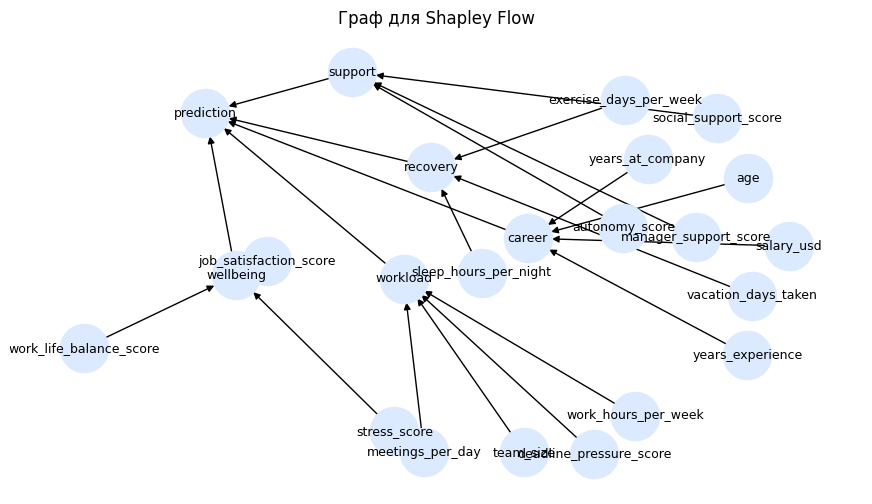

In [ ]:
import networkx as nx

flow_groups = {
    'career': ['age', 'years_experience', 'years_at_company', 'salary_usd'],
    'workload': ['work_hours_per_week', 'meetings_per_day', 'team_size', 'deadline_pressure_score'],
    'recovery': ['sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken'],
    'support': ['manager_support_score', 'social_support_score', 'autonomy_score'],
    'wellbeing': ['stress_score', 'work_life_balance_score', 'job_satisfaction_score']
}
flow_groups = {k: [c for c in v if c in X_fe_base.columns] for k, v in flow_groups.items()}
flow_groups = {k: v for k, v in flow_groups.items() if len(v) > 0}

flow_graph = nx.DiGraph()
for group, cols in flow_groups.items():
    for col in cols:
        flow_graph.add_edge(col, group)
    flow_graph.add_edge(group, 'prediction')

plt.figure(figsize=(11, 6))
pos = nx.spring_layout(flow_graph, seed=RANDOM_STATE)
nx.draw_networkx(flow_graph, pos=pos, node_size=1200, node_color='#dbeafe', font_size=9, arrows=True)
plt.title('Граф для Shapley Flow')
plt.axis('off')
plt.show()

In [ ]:
# Строим признаки-блоки: внутри каждого блока берём среднее стандартизированных исходных признаков.
flow_cols = sorted({col for cols in flow_groups.values() for col in cols})

flow_imputer = SimpleImputer(strategy='median')
flow_scaler = StandardScaler()
flow_scaled = pd.DataFrame(
    flow_scaler.fit_transform(flow_imputer.fit_transform(X_fe_base[flow_cols])),
    columns=flow_cols,
    index=X_fe_base.index
)

flow_blocks = pd.DataFrame(index=X_fe_base.index)
for group, cols in flow_groups.items():
    flow_blocks[group] = flow_scaled[cols].mean(axis=1)

flow_X_train, flow_X_test, flow_y_train, flow_y_test = train_test_split(
    flow_blocks,
    y_fe,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_fe
)

flow_rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=6,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1
)
flow_rf.fit(flow_X_train, flow_y_train)
flow_proba = flow_rf.predict_proba(flow_X_test)[:, 1]

flow_model_metrics = pd.DataFrame([{
    'model': 'RandomForest_on_flow_blocks',
    'roc_auc': roc_auc_score(flow_y_test, flow_proba),
    'accuracy': accuracy_score(flow_y_test, (flow_proba >= 0.5).astype(int))
}])
display(flow_model_metrics)

,model,roc_auc,accuracy
0,RandomForest_on_flow_blocks,0.620429,0.57775


In [ ]:
# SHAP по блокам трактуем как поток block -> prediction.
flow_explainer = shap.TreeExplainer(flow_rf)
flow_shap_train = binary_shap_values(flow_explainer.shap_values(flow_X_train, check_additivity=False))
flow_shap_test = binary_shap_values(flow_explainer.shap_values(flow_X_test, check_additivity=False))

flow_embed_train = pd.DataFrame(flow_shap_train, columns=flow_blocks.columns, index=flow_X_train.index)
flow_embed_test = pd.DataFrame(flow_shap_test, columns=flow_blocks.columns, index=flow_X_test.index)

flow_importance = pd.DataFrame({
    'edge': [f'{col}->prediction' for col in flow_blocks.columns],
    'mean_abs_flow': np.abs(flow_shap_test).mean(axis=0),
    'mean_flow': flow_shap_test.mean(axis=0)
}).sort_values('mean_abs_flow', ascending=False)

print('Глобальная интерпретация Shapley Flow')
display(flow_importance)

local_flow_i = np.argmax(flow_rf.predict_proba(flow_X_test)[:, 1])
local_flow = pd.DataFrame({
    'edge': [f'{col}->prediction' for col in flow_blocks.columns],
    'flow_value': flow_shap_test[local_flow_i]
}).assign(abs_flow=lambda x: x['flow_value'].abs()).sort_values('abs_flow', ascending=False)

print('Локальная интерпретация Shapley Flow')
display(local_flow)

Глобальная интерпретация Shapley Flow


,edge,mean_abs_flow,mean_flow
2,recovery->prediction,0.052301,-0.002860
1,workload->prediction,0.045662,-0.003575
3,support->prediction,0.029063,-0.001441
0,career->prediction,0.004511,-0.000352
4,wellbeing->prediction,0.004476,-0.000566


Локальная интерпретация Shapley Flow


,edge,flow_value,abs_flow
2,recovery->prediction,0.084758,0.084758
1,workload->prediction,0.068289,0.068289
3,support->prediction,0.033951,0.033951
4,wellbeing->prediction,0.006689,0.006689
0,career->prediction,0.000720,0.000720


In [ ]:
# Сдвиг, аномалии и кластеры в Flow-пространстве.
flow_shift = []
for col in flow_embed_train.columns:
    flow_shift.append({
        'flow_block': col,
        'psi_train_test': psi(flow_embed_train[col], flow_embed_test[col])
    })
flow_shift = pd.DataFrame(flow_shift).sort_values('psi_train_test', ascending=False)
display(flow_shift)

flow_outliers = IsolationForest(contamination=0.03, random_state=RANDOM_STATE, n_estimators=80)
flow_clean_mask = flow_outliers.fit_predict(flow_embed_train) == 1

flow_rf_before = clone(flow_rf)
flow_rf_after = clone(flow_rf)
flow_rf_before.fit(flow_X_train, flow_y_train)
flow_rf_after.fit(flow_X_train.loc[flow_clean_mask], flow_y_train.loc[flow_clean_mask])

flow_proba_before = flow_rf_before.predict_proba(flow_X_test)[:, 1]
flow_proba_after = flow_rf_after.predict_proba(flow_X_test)[:, 1]

flow_cleaning_metrics = pd.DataFrame([
    {
        'experiment': 'before_flow_cleaning',
        'roc_auc': roc_auc_score(flow_y_test, flow_proba_before),
        'accuracy': accuracy_score(flow_y_test, (flow_proba_before >= 0.5).astype(int))
    },
    {
        'experiment': 'after_flow_cleaning',
        'roc_auc': roc_auc_score(flow_y_test, flow_proba_after),
        'accuracy': accuracy_score(flow_y_test, (flow_proba_after >= 0.5).astype(int))
    }
])
display(flow_cleaning_metrics)

,flow_block,psi_train_test
2,recovery,0.000698
0,career,0.000646
1,workload,0.000527
3,support,0.000298
4,wellbeing,0.000280


,experiment,roc_auc,accuracy
0,before_flow_cleaning,0.620429,0.57775
1,after_flow_cleaning,0.621263,0.58160


## Итог этапа 3

На этом этапе были проведены интерпретация и диагностика моделей через LIME, SHAP, SHAP-эмбеддинги и упрощённый Shapley Flow.

Основной вывод: поведение моделей хорошо согласуется с логикой предметной области. На вероятность намерения сменить работу сильнее всего влияют стресс, тревожность, удовлетворённость работой, рабочая нагрузка, баланс работы и жизни, а также производные признаки вроде `stress_minus_balance` и `satisfaction_pressure_balance`.

Сильного сдвига между train и test в SHAP-пространстве не найдено: максимальный PSI ниже **0.1**. SHAP-аномалии и SHAP-кластеры дали небольшой прирост ROC-AUC примерно на **0.01**, но не радикально изменили качество. Это говорит о том, что диагностика помогла немного уточнить модель, но исходная структура данных уже достаточно стабильна.

Кросс-валидация показала, что SHAP-эмбеддинги можно использовать как самостоятельное компактное представление: вариант только на эмбеддингах дал ROC-AUC **0.6409**, а конкатенация с исходными признаками — **0.6087**. В этой постановке дополнительные исходные признаки скорее добавили шум.

Shapley Flow через смысловые блоки показал, что наиболее важны блоки восстановления, нагрузки и поддержки. Однако Flow-кластеры и очистка Flow-аномалий почти не улучшили метрики. Поэтому Flow стоит использовать прежде всего для объяснения структуры решений модели, а не как основной способ повышения качества.